# Importar librerias y datos

In [16]:
# ---------- IMPORTS ----------
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


import mlflow
import mlflow.sklearn
import mlflow.keras

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

In [2]:
path = "Resultados_ICFES_Cordoba_clean.csv"
df = pd.read_csv(path, encoding="utf-8-sig",low_memory=False)

# Filtro de Data frame y selección de variables necesarias

Filtrar data frame y mantener unicamente periodos relevantes

In [3]:
# Make sure periodo is numeric
df["periodo"] = pd.to_numeric(df["periodo"], errors="coerce")

# Remove rows with missing or invalid periodo
df = df.dropna(subset=["periodo"])

# Keep only records from 2015 onward
df = df[df["periodo"] > 20150].copy()

# Optional: reset index after filtering
df = df.reset_index(drop=True)

# Check result
print(df["periodo"].min())
print(df["periodo"].max())
print(df.shape)

20151
20224
(100094, 51)


Conteo y analisis de clases

In [4]:
# Make sure punt_matematicas is numeric
df["punt_matematicas"] = pd.to_numeric(df["punt_matematicas"], errors="coerce")

# Remove rows where the math score is missing
df = df.dropna(subset=["punt_matematicas"]).copy()

# Create target variable
# 1 if math score > 79
# 0 if math score <= 79
df["cumple_calculo"] = (df["punt_matematicas"] > 70).astype(int)

# Count and percentage of each class
conteo_clases = df["cumple_calculo"].value_counts()
porcentaje_clases = df["cumple_calculo"].value_counts(normalize=True) * 100

analisis_clases = pd.DataFrame({
    "Cantidad": conteo_clases,
    "Porcentaje": porcentaje_clases.round(2)
})

print(analisis_clases)

                Cantidad  Porcentaje
cumple_calculo                      
0                  96693        96.6
1                   3401         3.4


Definición de descriptores

In [5]:
df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"],
    errors="coerce",
    dayfirst=True
)

# Create year and application period
df["anio_periodo"] = (df["periodo"] // 10).astype(int)
df["periodo_aplicacion"] = (df["periodo"] % 10).astype(int)

df["edad_aprox"] = df["anio_periodo"] - df["estu_fechanacimiento"].dt.year

# Remove unrealistic ages
df.loc[(df["edad_aprox"] < 12) | (df["edad_aprox"] > 30), "edad_aprox"] = np.nan

# -------------------------------------------------------
# 4. Select recommended descriptors
# -------------------------------------------------------

features_recomendadas = [
    # Time variables
    "anio_periodo",
    "periodo_aplicacion",

    # School characteristics
    "cole_area_ubicacion",
    "cole_bilingue",
    "cole_calendario",
    "cole_caracter",
    "cole_genero",
    "cole_jornada",
    "cole_naturaleza",
    "cole_sede_principal",
    "cole_mcpio_ubicacion",

    # Student characteristics
    "edad_aprox",
    "estu_genero",
    "estu_mcpio_reside",

    # Family / socioeconomic variables
    "fami_cuartoshogar",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_estratovivienda",
    "fami_personashogar",
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneinternet",
    "fami_tienelavadora"
]

# Keep only columns that actually exist in the dataframe
features_recomendadas = [col for col in features_recomendadas if col in df.columns]

# Final dataframe for the model
df_modelo = df[features_recomendadas + ["cumple_calculo"]].copy()

print("\nSelected columns:")
print(df_modelo.columns.tolist())

print("\nShape of model dataframe:")
print(df_modelo.shape)




Selected columns:
['anio_periodo', 'periodo_aplicacion', 'cole_area_ubicacion', 'cole_bilingue', 'cole_calendario', 'cole_caracter', 'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_sede_principal', 'cole_mcpio_ubicacion', 'edad_aprox', 'estu_genero', 'estu_mcpio_reside', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'cumple_calculo']

Shape of model dataframe:
(100094, 24)


Eliminación de Nans

In [6]:
# -------------------------------------------------------
# Count classes before dropping NaNs
# -------------------------------------------------------

print("Class count BEFORE dropping NaNs:")
conteo_antes = df_modelo["cumple_calculo"].value_counts()
porcentaje_antes = df_modelo["cumple_calculo"].value_counts(normalize=True) * 100

balance_antes = pd.DataFrame({
    "Cantidad": conteo_antes,
    "Porcentaje": porcentaje_antes.round(2)
})

balance_antes.index = balance_antes.index.map({
    0: "No cumple requisito",
    1: "Cumple requisito"
})

print(balance_antes)

print("\nShape before dropping NaNs:")
print(df_modelo.shape)


# -------------------------------------------------------
# Drop all rows with NaNs
# -------------------------------------------------------

df_modelo_sin_nan = df_modelo.dropna().copy()

print("\nShape after dropping NaNs:")
print(df_modelo_sin_nan.shape)


# -------------------------------------------------------
# Count classes after dropping NaNs
# -------------------------------------------------------

print("\nClass count AFTER dropping NaNs:")
conteo_despues = df_modelo_sin_nan["cumple_calculo"].value_counts()
porcentaje_despues = df_modelo_sin_nan["cumple_calculo"].value_counts(normalize=True) * 100

balance_despues = pd.DataFrame({
    "Cantidad": conteo_despues,
    "Porcentaje": porcentaje_despues.round(2)
})

balance_despues.index = balance_despues.index.map({
    0: "No cumple requisito",
    1: "Cumple requisito"
})

print(balance_despues)

Class count BEFORE dropping NaNs:
                     Cantidad  Porcentaje
cumple_calculo                           
No cumple requisito     96693        96.6
Cumple requisito         3401         3.4

Shape before dropping NaNs:
(100094, 24)

Shape after dropping NaNs:
(29714, 24)

Class count AFTER dropping NaNs:
                     Cantidad  Porcentaje
cumple_calculo                           
No cumple requisito     28539       96.05
Cumple requisito         1175        3.95


# Pre entrenamiento

Train-test split

In [7]:
# Separate predictors and target
X = df_modelo_sin_nan.drop(columns=["cumple_calculo"])
y = df_modelo_sin_nan["cumple_calculo"]

# Stratified 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Check class distribution in training set
print("\nTraining class distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

# Check class distribution in testing set
print("\nTesting class distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train shape: (23771, 23)
X_test shape: (5943, 23)
y_train shape: (23771,)
y_test shape: (5943,)

Training class distribution:
cumple_calculo
0    22831
1      940
Name: count, dtype: int64
cumple_calculo
0    96.05
1     3.95
Name: proportion, dtype: float64

Testing class distribution:
cumple_calculo
0    5708
1     235
Name: count, dtype: int64
cumple_calculo
0    96.05
1     3.95
Name: proportion, dtype: float64


In [8]:
def creamodelos(info, xsize, lrate, dpout, lasso, ridge):
    modelo = keras.Sequential()

    modelo.add(keras.layers.Input(shape=(xsize,)))

    for i in info:
        modelo.add(
            keras.layers.Dense(
                i,
                activation="relu",
                kernel_regularizer=regularizers.l1_l2(lasso, ridge)
            )
        )
        modelo.add(keras.layers.Dropout(dpout))

    # Binary classification output
    modelo.add(keras.layers.Dense(1, activation="sigmoid"))

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lrate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )

    return modelo

In [9]:
lrate = 0.001
batch = 128
pasadas = 256

lasso = 0
ridge = 0
dpout = 0

info_capas = [
    [64, 32],
    [32, 32],
    [128, 64, 32],
    [64, 32, 32],
    [32, 32, 32],
    [256, 128, 128, 64, 32],
    [256, 256, 128, 64, 32],
    [256, 128, 128, 64, 32],
    [256, 256, 128, 128, 64, 32],
    [512, 256, 128, 64, 32]
]

In [9]:
# -------------------------------------------------------
# One-hot encode categorical variables
# -------------------------------------------------------

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

# One-hot encode X_train and X_test
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=False
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False
)

# Make sure train and test have exactly the same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

# Convert everything to float32 for TensorFlow
X_train_encoded = X_train_encoded.astype("float32")
X_test_encoded = X_test_encoded.astype("float32")

# Make sure y is numeric
y_train = y_train.astype(int)
y_test = y_test.astype(int)

Categorical columns:
['cole_area_ubicacion', 'cole_bilingue', 'cole_calendario', 'cole_caracter', 'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_sede_principal', 'cole_mcpio_ubicacion', 'estu_genero', 'estu_mcpio_reside', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora']


In [10]:
X_train = X_train_encoded.copy()
X_test = X_test_encoded.copy()

descr = X_train.shape[1]

In [16]:
mlflow.set_tracking_uri("http://localhost:5000")

experiment = mlflow.set_experiment("Arquitecturas")

2026/05/14 16:43:09 INFO mlflow.tracking.fluent: Experiment with name 'Arquitecturas' does not exist. Creating a new experiment.



Entrenando Modelo 1 con capas: [64, 32]
Modelo 1 | Fold 1 terminado — Val Acc: 0.7121, Val Recall: 0.8723, Val F1: 0.1933, Val AUC: 0.8583, Val Loss: 0.4878
Modelo 1 | Fold 2 terminado — Val Acc: 0.8231, Val Recall: 0.7021, Val F1: 0.2389, Val AUC: 0.8537, Val Loss: 0.3478
Modelo 1 | Fold 3 terminado — Val Acc: 0.7621, Val Recall: 0.8351, Val F1: 0.2173, Val AUC: 0.8707, Val Loss: 0.4678
Modelo 1 | Fold 4 terminado — Val Acc: 0.7160, Val Recall: 0.8457, Val F1: 0.1906, Val AUC: 0.8508, Val Loss: 0.5014
Modelo 1 | Fold 5 terminado — Val Acc: 0.6687, Val Recall: 0.8883, Val F1: 0.1750, Val AUC: 0.8501, Val Loss: 0.5786

Promedio de validación para esta arquitectura:
Accuracy promedio: 0.7364
Recall promedio: 0.8287
F1 promedio: 0.2030
AUC promedio: 0.8567
Loss promedio: 0.4767


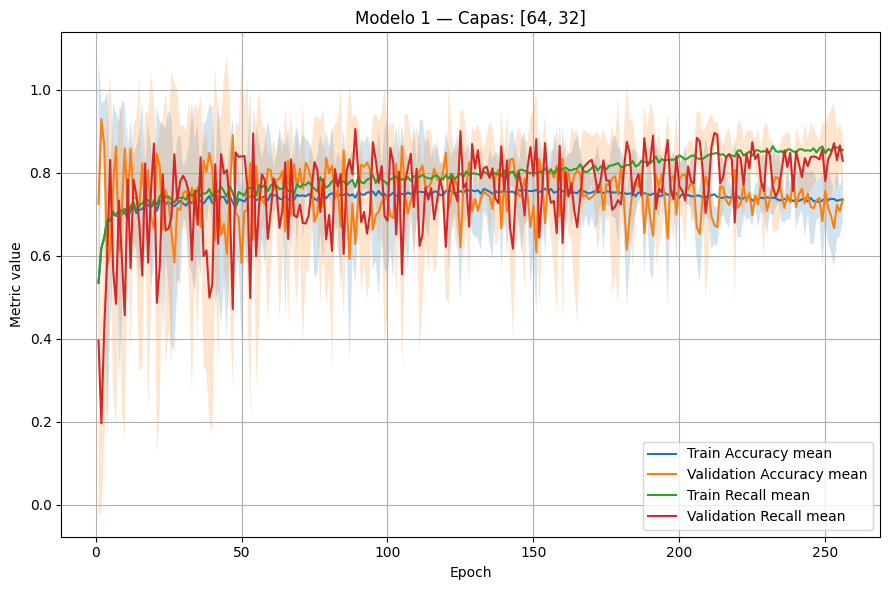

2026/05/14 20:19:22 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run Arquitectura [64, 32] at: http://localhost:5000/#/experiments/1/runs/a904fbedc8274273b85b4082c7a661c7
🧪 View experiment at: http://localhost:5000/#/experiments/1

Entrenando Modelo 2 con capas: [32, 32]
Modelo 2 | Fold 1 terminado — Val Acc: 0.6946, Val Recall: 0.8883, Val F1: 0.1870, Val AUC: 0.8571, Val Loss: 0.5250
Modelo 2 | Fold 2 terminado — Val Acc: 0.7413, Val Recall: 0.8351, Val F1: 0.2034, Val AUC: 0.8546, Val Loss: 0.4698
Modelo 2 | Fold 3 terminado — Val Acc: 0.7194, Val Recall: 0.8723, Val F1: 0.1974, Val AUC: 0.8697, Val Loss: 0.4905
Modelo 2 | Fold 4 terminado — Val Acc: 0.7806, Val Recall: 0.7553, Val F1: 0.2140, Val AUC: 0.8505, Val Loss: 0.4050
Modelo 2 | Fold 5 terminado — Val Acc: 0.7303, Val Recall: 0.8564, Val F1: 0.2007, Val AUC: 0.8524, Val Loss: 0.4689

Promedio de validación para esta arquitectura:
Accuracy promedio: 0.7332
Recall promedio: 0.8415
F1 promedio: 0.2005
AUC promedio: 0.8569
Loss promedio: 0.4718


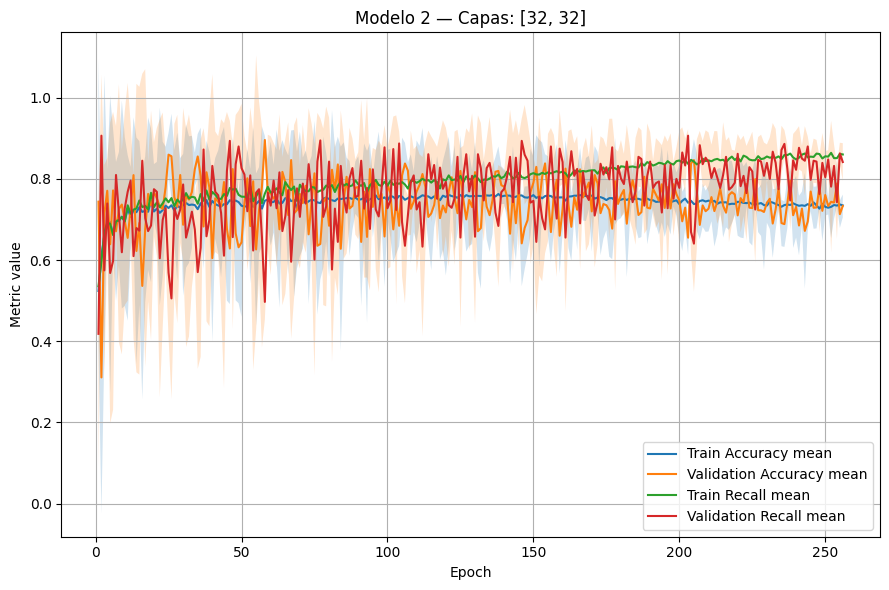

2026/05/14 20:43:35 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run Arquitectura [32, 32] at: http://localhost:5000/#/experiments/1/runs/d2d3fb4f3d034501aa5e2f58663ae700
🧪 View experiment at: http://localhost:5000/#/experiments/1

Entrenando Modelo 3 con capas: [128, 64, 32]
Modelo 3 | Fold 1 terminado — Val Acc: 0.7920, Val Recall: 0.7819, Val F1: 0.2292, Val AUC: 0.8614, Val Loss: 0.3955
Modelo 3 | Fold 2 terminado — Val Acc: 0.6153, Val Recall: 0.9362, Val F1: 0.1614, Val AUC: 0.8579, Val Loss: 0.6429
Modelo 3 | Fold 3 terminado — Val Acc: 0.5940, Val Recall: 0.9521, Val F1: 0.1565, Val AUC: 0.8687, Val Loss: 0.6454
Modelo 3 | Fold 4 terminado — Val Acc: 0.7183, Val Recall: 0.8298, Val F1: 0.1890, Val AUC: 0.8494, Val Loss: 0.4702
Modelo 3 | Fold 5 terminado — Val Acc: 0.7764, Val Recall: 0.7766, Val F1: 0.2155, Val AUC: 0.8503, Val Loss: 0.3885

Promedio de validación para esta arquitectura:
Accuracy promedio: 0.6992
Recall promedio: 0.8553
F1 promedio: 0.1903
AUC promedio: 0.8575
Loss promedio: 0.5085


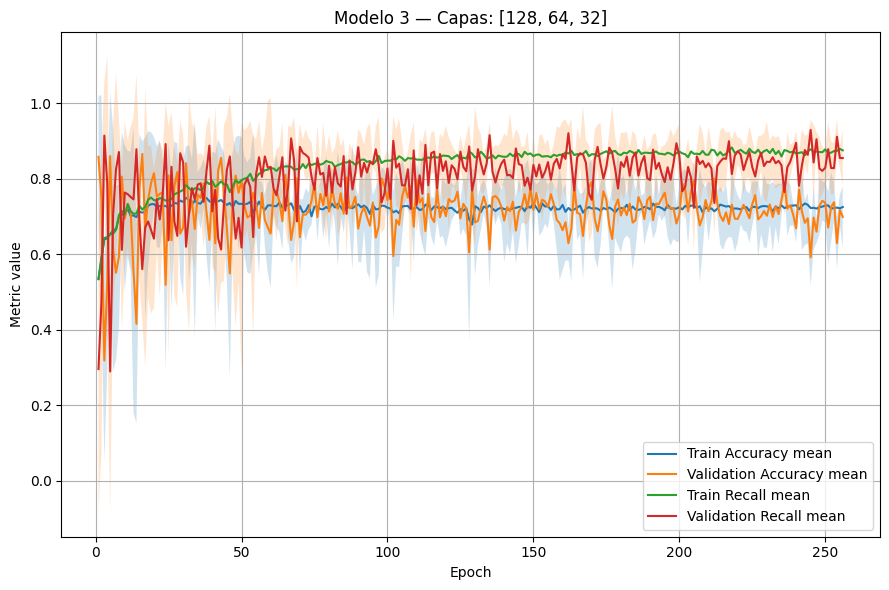

2026/05/14 21:01:19 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run Arquitectura [128, 64, 32] at: http://localhost:5000/#/experiments/1/runs/35bd8138e21243ae954672bc654f19b2
🧪 View experiment at: http://localhost:5000/#/experiments/1

Entrenando Modelo 4 con capas: [64, 32, 32]
Modelo 4 | Fold 1 terminado — Val Acc: 0.4042, Val Recall: 0.9787, Val F1: 0.1150, Val AUC: 0.8559, Val Loss: 0.9764
Modelo 4 | Fold 2 terminado — Val Acc: 0.6862, Val Recall: 0.8830, Val F1: 0.1820, Val AUC: 0.8554, Val Loss: 0.5663
Modelo 4 | Fold 3 terminado — Val Acc: 0.8065, Val Recall: 0.7766, Val F1: 0.2409, Val AUC: 0.8702, Val Loss: 0.3651
Modelo 4 | Fold 4 terminado — Val Acc: 0.6601, Val Recall: 0.8989, Val F1: 0.1730, Val AUC: 0.8478, Val Loss: 0.5694
Modelo 4 | Fold 5 terminado — Val Acc: 0.9032, Val Recall: 0.4574, Val F1: 0.2722, Val AUC: 0.8454, Val Loss: 0.2102

Promedio de validación para esta arquitectura:
Accuracy promedio: 0.6920
Recall promedio: 0.7989
F1 promedio: 0.1966
AUC promedio: 0.8549
Loss promedio: 0.5375


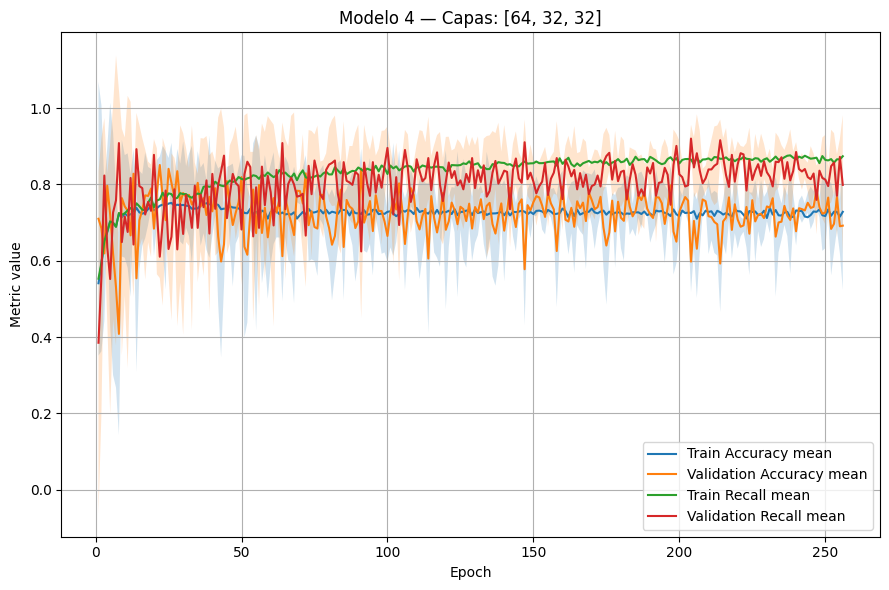

2026/05/14 21:21:37 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run Arquitectura [64, 32, 32] at: http://localhost:5000/#/experiments/1/runs/9f1f73be6ada499396fd6278bf73f109
🧪 View experiment at: http://localhost:5000/#/experiments/1

Entrenando Modelo 5 con capas: [32, 32, 32]
Modelo 5 | Fold 1 terminado — Val Acc: 0.7056, Val Recall: 0.8723, Val F1: 0.1898, Val AUC: 0.8558, Val Loss: 0.4928
Modelo 5 | Fold 2 terminado — Val Acc: 0.7644, Val Recall: 0.8032, Val F1: 0.2124, Val AUC: 0.8526, Val Loss: 0.4249
Modelo 5 | Fold 3 terminado — Val Acc: 0.7793, Val Recall: 0.8085, Val F1: 0.2247, Val AUC: 0.8707, Val Loss: 0.4038
Modelo 5 | Fold 4 terminado — Val Acc: 0.7045, Val Recall: 0.8511, Val F1: 0.1855, Val AUC: 0.8501, Val Loss: 0.4650
Modelo 5 | Fold 5 terminado — Val Acc: 0.7518, Val Recall: 0.8351, Val F1: 0.2102, Val AUC: 0.8518, Val Loss: 0.3856

Promedio de validación para esta arquitectura:
Accuracy promedio: 0.7411
Recall promedio: 0.8340
F1 promedio: 0.2045
AUC promedio: 0.8562
Loss promedio: 0.4344


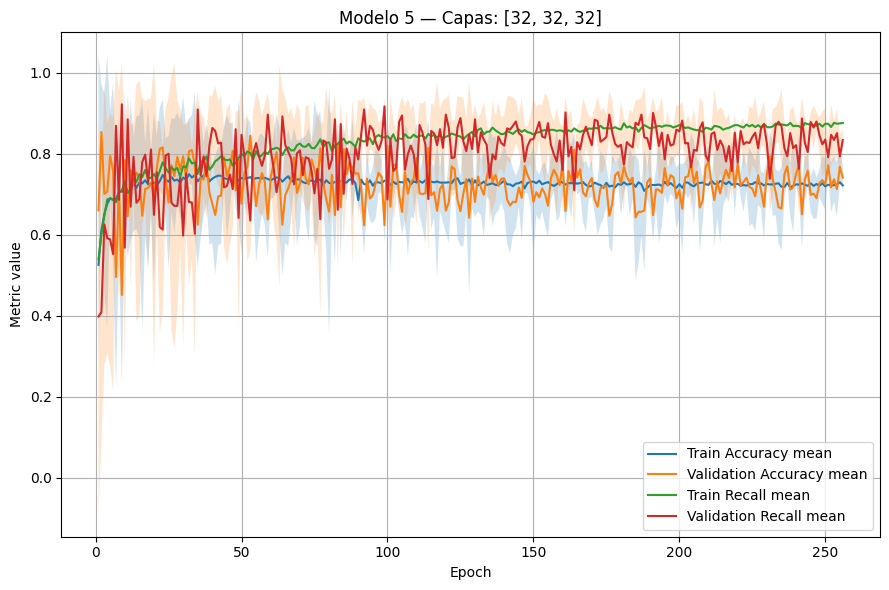

2026/05/14 21:42:01 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run Arquitectura [32, 32, 32] at: http://localhost:5000/#/experiments/1/runs/ea8f3a733b614156993be39f8f1c7157
🧪 View experiment at: http://localhost:5000/#/experiments/1

Entrenando Modelo 6 con capas: [256, 128, 128, 64, 32]
Modelo 6 | Fold 1 terminado — Val Acc: 0.7371, Val Recall: 0.8457, Val F1: 0.2028, Val AUC: 0.8559, Val Loss: 0.4768
Modelo 6 | Fold 2 terminado — Val Acc: 0.5782, Val Recall: 0.9415, Val F1: 0.1501, Val AUC: 0.8597, Val Loss: 0.7219
Modelo 6 | Fold 3 terminado — Val Acc: 0.9605, Val Recall: 0.0000, Val F1: 0.0000, Val AUC: 0.5000, Val Loss: 0.6929
Modelo 6 | Fold 4 terminado — Val Acc: 0.6512, Val Recall: 0.8989, Val F1: 0.1693, Val AUC: 0.8487, Val Loss: 0.6058
Modelo 6 | Fold 5 terminado — Val Acc: 0.9605, Val Recall: 0.0000, Val F1: 0.0000, Val AUC: 0.5000, Val Loss: 0.6929

Promedio de validación para esta arquitectura:
Accuracy promedio: 0.7775
Recall promedio: 0.5372
F1 promedio: 0.1044
AUC promedio: 0.7129
Loss promedio: 0.6381


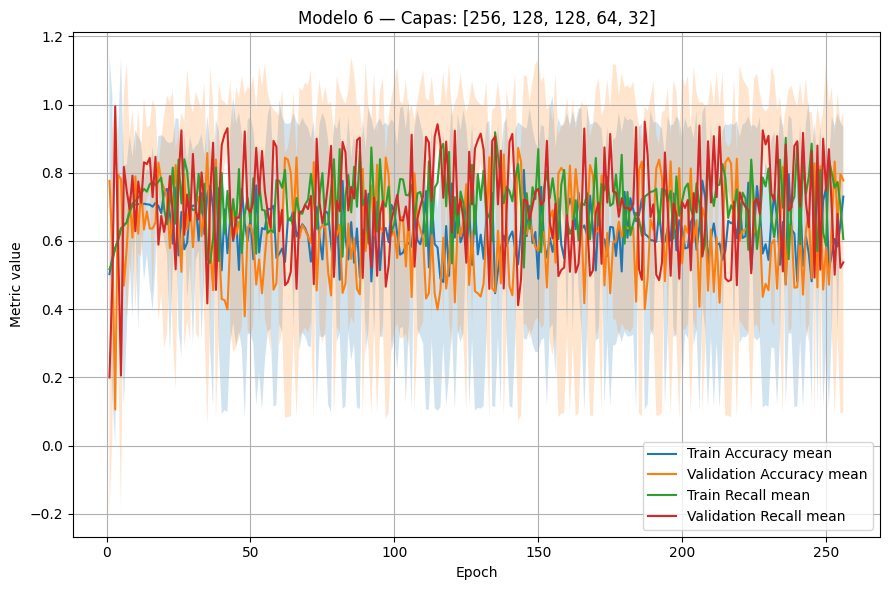

2026/05/14 22:14:06 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run Arquitectura [256, 128, 128, 64, 32] at: http://localhost:5000/#/experiments/1/runs/18caebabe68247438f86c933d7960f49
🧪 View experiment at: http://localhost:5000/#/experiments/1

Entrenando Modelo 7 con capas: [256, 256, 128, 64, 32]
Modelo 7 | Fold 1 terminado — Val Acc: 0.7676, Val Recall: 0.8351, Val F1: 0.2213, Val AUC: 0.8607, Val Loss: 0.4193
Modelo 7 | Fold 2 terminado — Val Acc: 0.7842, Val Recall: 0.7766, Val F1: 0.2215, Val AUC: 0.8529, Val Loss: 0.3904
Modelo 7 | Fold 3 terminado — Val Acc: 0.7347, Val Recall: 0.8670, Val F1: 0.2054, Val AUC: 0.8700, Val Loss: 0.4625
Modelo 7 | Fold 4 terminado — Val Acc: 0.9605, Val Recall: 0.0000, Val F1: 0.0000, Val AUC: 0.5000, Val Loss: 0.6922
Modelo 7 | Fold 5 terminado — Val Acc: 0.7253, Val Recall: 0.8564, Val F1: 0.1978, Val AUC: 0.8519, Val Loss: 0.4523

Promedio de validación para esta arquitectura:
Accuracy promedio: 0.7945
Recall promedio: 0.6670
F1 promedio: 0.1692
AUC promedio: 0.7871
Loss promedio: 0.4833


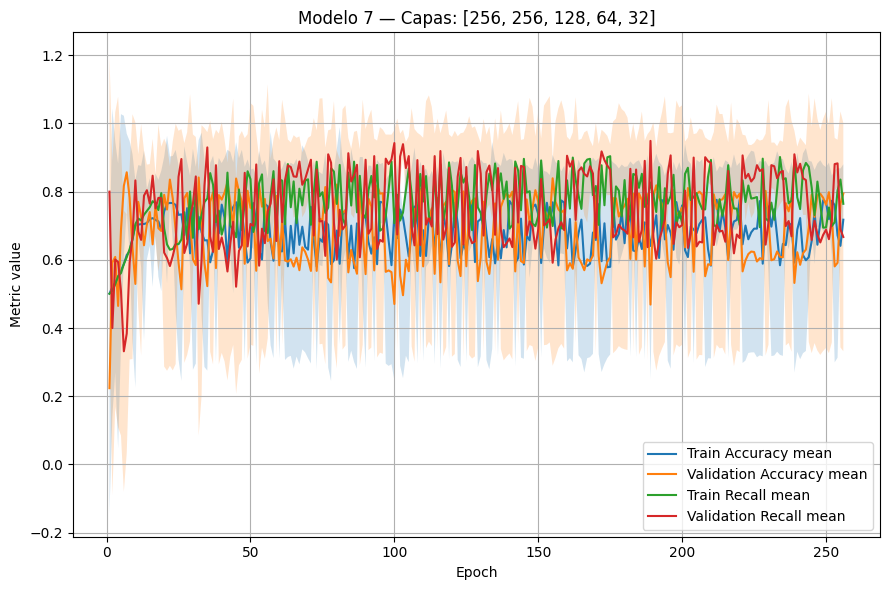

2026/05/14 22:52:11 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run Arquitectura [256, 256, 128, 64, 32] at: http://localhost:5000/#/experiments/1/runs/03f45e07839c46bf8935ea4d4464b613
🧪 View experiment at: http://localhost:5000/#/experiments/1

Entrenando Modelo 8 con capas: [256, 128, 128, 64, 32]
Modelo 8 | Fold 1 terminado — Val Acc: 0.6772, Val Recall: 0.9043, Val F1: 0.1813, Val AUC: 0.8571, Val Loss: 0.5465
Modelo 8 | Fold 2 terminado — Val Acc: 0.7209, Val Recall: 0.8617, Val F1: 0.1962, Val AUC: 0.8513, Val Loss: 0.5136
Modelo 8 | Fold 3 terminado — Val Acc: 0.3790, Val Recall: 0.9787, Val F1: 0.1108, Val AUC: 0.8697, Val Loss: 1.0413
Modelo 8 | Fold 4 terminado — Val Acc: 0.6761, Val Recall: 0.8777, Val F1: 0.1765, Val AUC: 0.8477, Val Loss: 0.5200


In [ ]:
# -------------------------------------------------------
# Stratified K-Fold
# -------------------------------------------------------

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# General storage
resultados_modelos = []

all_valid_acc = []
all_train_acc = []
all_valid_recall = []
all_train_recall = []
all_valid_auc = []
all_valid_loss = []

contador = 1

for arquitectura in info_capas:

    run_name = f"Arquitectura {arquitectura}"

    with mlflow.start_run(
        experiment_id=experiment.experiment_id,
        run_name=run_name
    ):

        print("\n" + "="*70)
        print(f"Entrenando Modelo {contador} con capas: {arquitectura}")
        print("="*70)

        # -------------------------------------------------------
        # Log hyperparameters in MLflow
        # -------------------------------------------------------

        mlflow.log_param("arquitectura", str(arquitectura))
        mlflow.log_param("num_capas_ocultas", len(arquitectura))
        mlflow.log_param("neuronas_por_capa", str(arquitectura))
        mlflow.log_param("learning_rate", lrate)
        mlflow.log_param("batch_size", batch)
        mlflow.log_param("epochs", pasadas)
        mlflow.log_param("lasso_l1", lasso)
        mlflow.log_param("ridge_l2", ridge)
        mlflow.log_param("dropout", dpout)
        mlflow.log_param("n_splits", 5)
        mlflow.log_param("tipo_validacion", "StratifiedKFold")
        mlflow.log_param("num_descriptores", descr)

        model_valid_acc = []
        model_train_acc = []
        model_valid_recall = []
        model_train_recall = []
        model_valid_auc = []
        model_valid_loss = []

        fold_metrics = []

        best_fold_recall = -1
        best_fold_model = None
        best_fold_number = None

        fold_number = 1

        for train_index, val_index in kf.split(X_train, y_train):

            X_tr = X_train.iloc[train_index]
            X_val = X_train.iloc[val_index]

            y_tr = y_train.iloc[train_index]
            y_val = y_train.iloc[val_index]

            # -------------------------------------------------------
            # Class weights for imbalanced target
            # -------------------------------------------------------

            clases = np.unique(y_tr)

            pesos = compute_class_weight(
                class_weight="balanced",
                classes=clases,
                y=y_tr
            )

            class_weight_dict = dict(zip(clases, pesos))

            # -------------------------------------------------------
            # Create and train model
            # -------------------------------------------------------

            modelo = creamodelos(
                arquitectura,
                descr,
                lrate,
                dpout,
                lasso,
                ridge
            )

            train = modelo.fit(
                X_tr,
                y_tr,
                batch_size=batch,
                epochs=pasadas,
                validation_data=(X_val, y_val),
                class_weight=class_weight_dict,
                verbose=0
            )

            # -------------------------------------------------------
            # Final epoch metrics from Keras
            # -------------------------------------------------------

            last_train_acc = train.history["accuracy"][-1]
            last_val_acc = train.history["val_accuracy"][-1]
            last_train_recall = train.history["recall"][-1]
            last_val_recall_keras = train.history["val_recall"][-1]
            last_val_auc_keras = train.history["val_auc"][-1]
            last_val_loss = train.history["val_loss"][-1]

            # -------------------------------------------------------
            # Predictions for sklearn metrics
            # -------------------------------------------------------

            y_prob = modelo.predict(X_val, verbose=0).ravel()
            y_pred = (y_prob >= 0.5).astype(int)

            fold_recall = recall_score(y_val, y_pred, zero_division=0)
            fold_f1 = f1_score(y_val, y_pred, zero_division=0)
            fold_auc = roc_auc_score(y_val, y_prob)

            print(
                f"Modelo {contador} | Fold {fold_number} terminado — "
                f"Val Acc: {last_val_acc:.4f}, "
                f"Val Recall: {fold_recall:.4f}, "
                f"Val F1: {fold_f1:.4f}, "
                f"Val AUC: {fold_auc:.4f}, "
                f"Val Loss: {last_val_loss:.4f}"
            )

            # -------------------------------------------------------
            # Save curves for plotting
            # -------------------------------------------------------

            model_valid_acc.append(np.array(train.history["val_accuracy"]))
            model_train_acc.append(np.array(train.history["accuracy"]))
            model_valid_recall.append(np.array(train.history["val_recall"]))
            model_train_recall.append(np.array(train.history["recall"]))
            model_valid_auc.append(np.array(train.history["val_auc"]))
            model_valid_loss.append(np.array(train.history["val_loss"]))

            # -------------------------------------------------------
            # Save fold metrics
            # -------------------------------------------------------

            fold_result = {
                "modelo": contador,
                "capas": arquitectura,
                "fold": fold_number,
                "val_accuracy": last_val_acc,
                "val_recall": fold_recall,
                "val_f1": fold_f1,
                "val_auc": fold_auc,
                "val_loss": last_val_loss
            }

            fold_metrics.append(fold_result)
            resultados_modelos.append(fold_result)

            # -------------------------------------------------------
            # Log individual fold metrics in MLflow
            # -------------------------------------------------------

            mlflow.log_metric(f"fold_{fold_number}_val_accuracy", last_val_acc)
            mlflow.log_metric(f"fold_{fold_number}_val_recall", fold_recall)
            mlflow.log_metric(f"fold_{fold_number}_val_f1", fold_f1)
            mlflow.log_metric(f"fold_{fold_number}_val_auc", fold_auc)
            mlflow.log_metric(f"fold_{fold_number}_val_loss", last_val_loss)

            # -------------------------------------------------------
            # Keep best fold model according to recall
            # -------------------------------------------------------

            if fold_recall > best_fold_recall:
                best_fold_recall = fold_recall
                best_fold_model = modelo
                best_fold_number = fold_number

            fold_number += 1

        # -------------------------------------------------------
        # Calculate average metrics across 5 folds
        # -------------------------------------------------------

        df_fold_metrics = pd.DataFrame(fold_metrics)

        mean_val_accuracy = df_fold_metrics["val_accuracy"].mean()
        mean_val_recall = df_fold_metrics["val_recall"].mean()
        mean_val_f1 = df_fold_metrics["val_f1"].mean()
        mean_val_auc = df_fold_metrics["val_auc"].mean()
        mean_val_loss = df_fold_metrics["val_loss"].mean()

        std_val_accuracy = df_fold_metrics["val_accuracy"].std()
        std_val_recall = df_fold_metrics["val_recall"].std()
        std_val_f1 = df_fold_metrics["val_f1"].std()
        std_val_auc = df_fold_metrics["val_auc"].std()
        std_val_loss = df_fold_metrics["val_loss"].std()

        print("\nPromedio de validación para esta arquitectura:")
        print(f"Accuracy promedio: {mean_val_accuracy:.4f}")
        print(f"Recall promedio: {mean_val_recall:.4f}")
        print(f"F1 promedio: {mean_val_f1:.4f}")
        print(f"AUC promedio: {mean_val_auc:.4f}")
        print(f"Loss promedio: {mean_val_loss:.4f}")

        # -------------------------------------------------------
        # Log average metrics in MLflow
        # -------------------------------------------------------

        mlflow.log_metric("mean_val_accuracy", mean_val_accuracy)
        mlflow.log_metric("mean_val_recall", mean_val_recall)
        mlflow.log_metric("mean_val_f1", mean_val_f1)
        mlflow.log_metric("mean_val_auc", mean_val_auc)
        mlflow.log_metric("mean_val_loss", mean_val_loss)

        mlflow.log_metric("std_val_accuracy", std_val_accuracy)
        mlflow.log_metric("std_val_recall", std_val_recall)
        mlflow.log_metric("std_val_f1", std_val_f1)
        mlflow.log_metric("std_val_auc", std_val_auc)
        mlflow.log_metric("std_val_loss", std_val_loss)

        mlflow.log_metric("best_fold_recall", best_fold_recall)
        mlflow.log_param("best_fold_number", best_fold_number)

        # -------------------------------------------------------
        # Log fold metrics as CSV artifact
        # -------------------------------------------------------

        fold_csv_path = f"fold_metrics_modelo_{contador}.csv"
        df_fold_metrics.to_csv(fold_csv_path, index=False)

        mlflow.log_artifact(fold_csv_path)

        # -------------------------------------------------------
        # Average curves across folds
        # -------------------------------------------------------

        val_acc_mean = np.mean(model_valid_acc, axis=0)
        val_acc_std = np.std(model_valid_acc, axis=0)

        train_acc_mean = np.mean(model_train_acc, axis=0)

        val_recall_mean = np.mean(model_valid_recall, axis=0)
        val_recall_std = np.std(model_valid_recall, axis=0)

        train_recall_mean = np.mean(model_train_recall, axis=0)

        epochs_range = np.arange(1, len(val_acc_mean) + 1)

        # -------------------------------------------------------
        # Graph accuracy and recall
        # -------------------------------------------------------

        plt.figure(figsize=(9, 6))

        plt.plot(epochs_range, train_acc_mean, label="Train Accuracy mean")
        plt.plot(epochs_range, val_acc_mean, label="Validation Accuracy mean")
        plt.fill_between(
            epochs_range,
            val_acc_mean - val_acc_std,
            val_acc_mean + val_acc_std,
            alpha=0.2
        )

        plt.plot(epochs_range, train_recall_mean, label="Train Recall mean")
        plt.plot(epochs_range, val_recall_mean, label="Validation Recall mean")
        plt.fill_between(
            epochs_range,
            val_recall_mean - val_recall_std,
            val_recall_mean + val_recall_std,
            alpha=0.2
        )

        plt.xlabel("Epoch")
        plt.ylabel("Metric value")
        plt.title(f"Modelo {contador} — Capas: {arquitectura}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        plot_path = f"curvas_modelo_{contador}.png"
        plt.savefig(plot_path, dpi=150)
        plt.show()

        mlflow.log_artifact(plot_path)

        # -------------------------------------------------------
        # Log best fold model as artifact
        # -------------------------------------------------------

        mlflow.keras.log_model(
            best_fold_model,
            name="best-fold-keras-model"
        )

        # -------------------------------------------------------
        # Store full curves
        # -------------------------------------------------------

        all_valid_acc.append(np.stack(model_valid_acc))
        all_train_acc.append(np.stack(model_train_acc))
        all_valid_recall.append(np.stack(model_valid_recall))
        all_train_recall.append(np.stack(model_train_recall))
        all_valid_auc.append(np.stack(model_valid_auc))
        all_valid_loss.append(np.stack(model_valid_loss))

    contador += 1

In [ ]:
# Convert list of dictionaries into DataFrame
df_resultados = pd.DataFrame(resultados_modelos)
resumen_modelos = df_resultados.groupby("modelo").agg({
    "val_accuracy": "mean",
    "val_f1": "mean",
    "val_recall": "mean",
    "val_auc": "mean",
    "val_loss": "mean"
}).reset_index()

resumen_modelos = resumen_modelos.rename(columns={
    "val_accuracy": "accuracy_promedio",
    "val_f1": "f1_promedio",
    "val_recall": "recall_promedio",
    "val_auc": "auc_promedio",
    "val_loss": "loss_promedio"
})

print(resumen_modelos)

   modelo  accuracy_promedio  f1_promedio  recall_promedio  auc_promedio  \
0       1           0.692271     0.186288         0.871277      0.856223   
1       2           0.718225     0.201059         0.807447      0.856557   
2       3           0.682008     0.182904         0.864894      0.854983   
3       4           0.760593     0.211973         0.805319      0.855043   
4       5           0.748558     0.210267         0.819149      0.856863   
5       6           0.720205     0.196900         0.856383      0.855614   
6       7           0.712000     0.193007         0.861702      0.856548   
7       8           0.762265     0.154616         0.682979      0.785478   
8       9           0.645702     0.169795         0.905319      0.856524   
9      10           0.769929     0.218315         0.804255      0.856985   

   loss_promedio  
0       0.500384  
1       0.487953  
2       0.546501  
3       0.425412  
4       0.445943  
5       0.491884  
6       0.495842  
7       0.5

In [ ]:
resumen_modelos_ordenado = resumen_modelos.sort_values(
    by="recall_promedio",
    ascending=False
)

print(resumen_modelos_ordenado)

   modelo  accuracy_promedio  f1_promedio  recall_promedio  auc_promedio  \
8       9           0.645702     0.169795         0.905319      0.856524   
0       1           0.692271     0.186288         0.871277      0.856223   
2       3           0.682008     0.182904         0.864894      0.854983   
6       7           0.712000     0.193007         0.861702      0.856548   
5       6           0.720205     0.196900         0.856383      0.855614   
4       5           0.748558     0.210267         0.819149      0.856863   
1       2           0.718225     0.201059         0.807447      0.856557   
3       4           0.760593     0.211973         0.805319      0.855043   
9      10           0.769929     0.218315         0.804255      0.856985   
7       8           0.762265     0.154616         0.682979      0.785478   

   loss_promedio  
8       0.605178  
0       0.500384  
2       0.546501  
6       0.495842  
5       0.491884  
4       0.445943  
1       0.487953  
3       0.4

In [12]:
mlflow.set_tracking_uri("http://localhost:5000")
experiment = mlflow.set_experiment("Tasa de aprendizaje")

2026/05/19 21:41:47 INFO mlflow.tracking.fluent: Experiment with name 'Tasa de aprendizaje' does not exist. Creating a new experiment.


In [13]:
# -------------------------------------------------------
# Hyperparameters for learning rate experiment
# -------------------------------------------------------

batch = 128
pasadas = 256

lasso = 0
ridge = 0
dpout = 0

# Best architecture found in previous experiment
arquitectura_fija = [256, 256, 128, 128, 64, 32]

# Learning rates to evaluate
learning_rates = [
    0.0001,
    0.0003,
    0.0005,
    0.001,
    0.002,
    0.0035,
    0.005
]

print("Arquitectura fija:", arquitectura_fija)
print("Learning rates to evaluate:", learning_rates)

Arquitectura fija: [256, 256, 128, 128, 64, 32]
Learning rates to evaluate: [0.0001, 0.0003, 0.0005, 0.001, 0.002, 0.0035, 0.005]



Entrenando modelo con learning rate: 0.0001
Arquitectura fija: [256, 256, 128, 128, 64, 32]

LR 0.0001 | Fold 1 terminado — Val Acc: 0.6526, Val Recall: 0.9043, Val F1: 0.1707, Val AUC: 0.8562, Val Loss: 0.6119
LR 0.0001 | Fold 2 terminado — Val Acc: 0.5183, Val Recall: 0.9521, Val F1: 0.1352, Val AUC: 0.8509, Val Loss: 0.8602
LR 0.0001 | Fold 3 terminado — Val Acc: 0.8010, Val Recall: 0.7819, Val F1: 0.2371, Val AUC: 0.8704, Val Loss: 0.3778
LR 0.0001 | Fold 4 terminado — Val Acc: 0.6481, Val Recall: 0.9096, Val F1: 0.1697, Val AUC: 0.8492, Val Loss: 0.5926
LR 0.0001 | Fold 5 terminado — Val Acc: 0.6872, Val Recall: 0.8883, Val F1: 0.1834, Val AUC: 0.8488, Val Loss: 0.5352

Promedio de validación para este learning rate:
Learning rate: 0.0001
Accuracy promedio: 0.6614
Recall promedio: 0.8872
F1 promedio: 0.1792
AUC promedio: 0.8551
Loss promedio: 0.5955


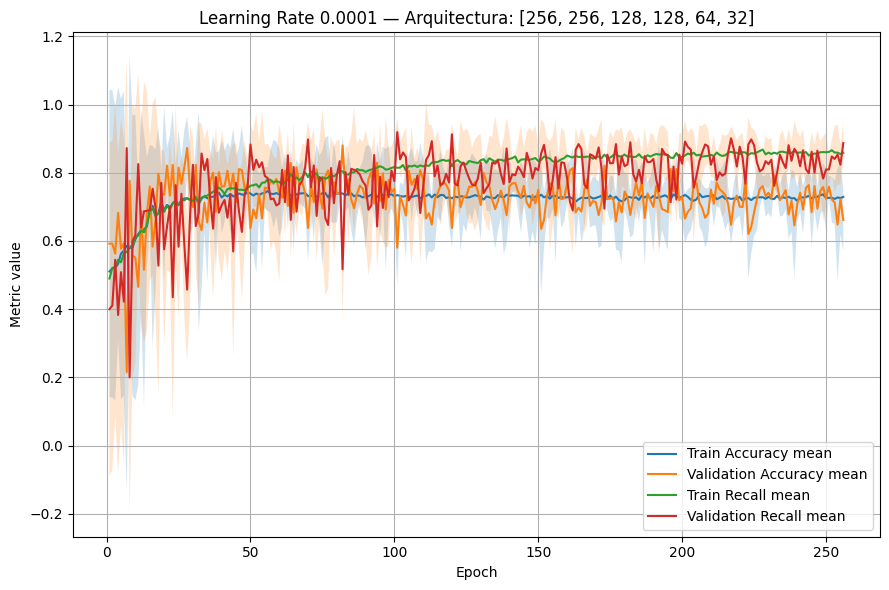

🏃 View run LR 0.0001 at: http://localhost:5000/#/experiments/2/runs/fd2bd94ed744416994b5919e284d536f
🧪 View experiment at: http://localhost:5000/#/experiments/2

Entrenando modelo con learning rate: 0.0003
Arquitectura fija: [256, 256, 128, 128, 64, 32]
LR 0.0003 | Fold 1 terminado — Val Acc: 0.7195, Val Recall: 0.8723, Val F1: 0.1974, Val AUC: 0.8586, Val Loss: 0.4753
LR 0.0003 | Fold 2 terminado — Val Acc: 0.7068, Val Recall: 0.8617, Val F1: 0.1886, Val AUC: 0.8526, Val Loss: 0.5039
LR 0.0003 | Fold 3 terminado — Val Acc: 0.7974, Val Recall: 0.7926, Val F1: 0.2363, Val AUC: 0.8699, Val Loss: 0.3845
LR 0.0003 | Fold 4 terminado — Val Acc: 0.7118, Val Recall: 0.8457, Val F1: 0.1884, Val AUC: 0.8503, Val Loss: 0.4732
LR 0.0003 | Fold 5 terminado — Val Acc: 0.8113, Val Recall: 0.7128, Val F1: 0.2300, Val AUC: 0.8477, Val Loss: 0.3554

Promedio de validación para este learning rate:
Learning rate: 0.0003
Accuracy promedio: 0.7494
Recall promedio: 0.8170
F1 promedio: 0.2081
AUC promedio: 0

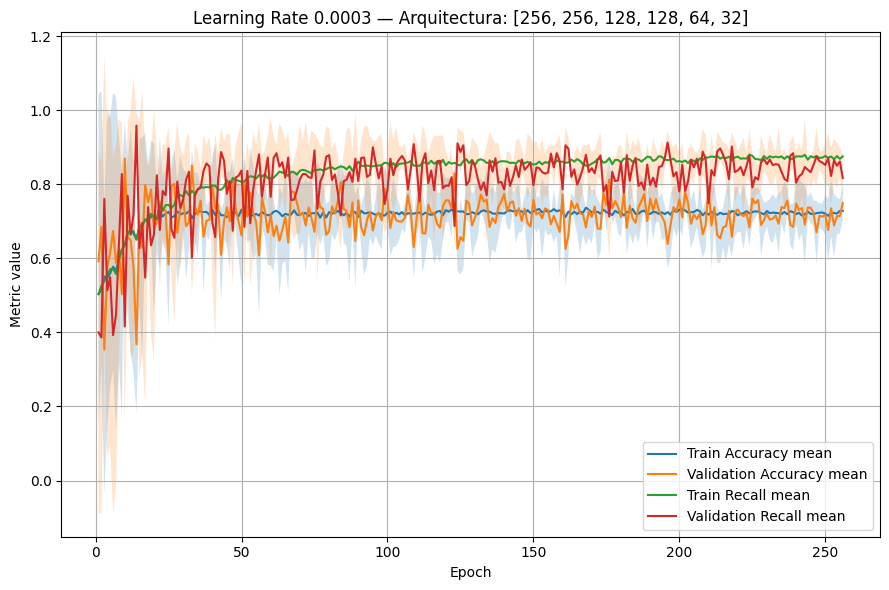

🏃 View run LR 0.0003 at: http://localhost:5000/#/experiments/2/runs/95bb3746c275496b987fa17e8ac19d1c
🧪 View experiment at: http://localhost:5000/#/experiments/2

Entrenando modelo con learning rate: 0.0005
Arquitectura fija: [256, 256, 128, 128, 64, 32]
LR 0.0005 | Fold 1 terminado — Val Acc: 0.7624, Val Recall: 0.8245, Val F1: 0.2153, Val AUC: 0.8582, Val Loss: 0.4452
LR 0.0005 | Fold 2 terminado — Val Acc: 0.7335, Val Recall: 0.8457, Val F1: 0.2006, Val AUC: 0.8540, Val Loss: 0.4422
LR 0.0005 | Fold 3 terminado — Val Acc: 0.7562, Val Recall: 0.8404, Val F1: 0.2142, Val AUC: 0.8703, Val Loss: 0.4276
LR 0.0005 | Fold 4 terminado — Val Acc: 0.7970, Val Recall: 0.7128, Val F1: 0.2174, Val AUC: 0.8503, Val Loss: 0.3846
LR 0.0005 | Fold 5 terminado — Val Acc: 0.7751, Val Recall: 0.7926, Val F1: 0.2180, Val AUC: 0.8518, Val Loss: 0.4255

Promedio de validación para este learning rate:
Learning rate: 0.0005
Accuracy promedio: 0.7648
Recall promedio: 0.8032
F1 promedio: 0.2131
AUC promedio: 0

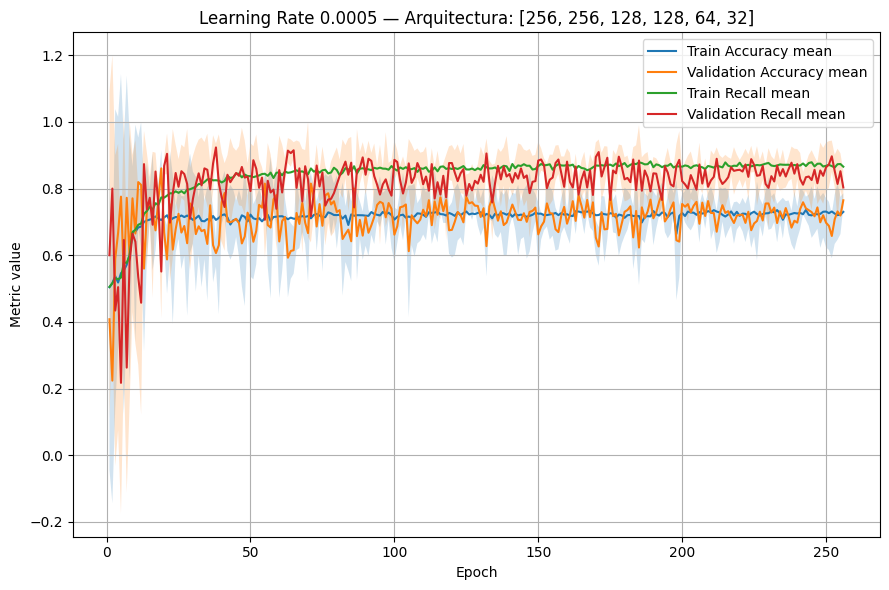

🏃 View run LR 0.0005 at: http://localhost:5000/#/experiments/2/runs/809f10e6e16146acba185403b97b2e84
🧪 View experiment at: http://localhost:5000/#/experiments/2

Entrenando modelo con learning rate: 0.001
Arquitectura fija: [256, 256, 128, 128, 64, 32]
LR 0.001 | Fold 1 terminado — Val Acc: 0.8048, Val Recall: 0.7660, Val F1: 0.2368, Val AUC: 0.8614, Val Loss: 0.3621
LR 0.001 | Fold 2 terminado — Val Acc: 0.7204, Val Recall: 0.8670, Val F1: 0.1970, Val AUC: 0.8550, Val Loss: 0.4743
LR 0.001 | Fold 3 terminado — Val Acc: 0.6355, Val Recall: 0.9202, Val F1: 0.1664, Val AUC: 0.8706, Val Loss: 0.6219
LR 0.001 | Fold 4 terminado — Val Acc: 0.7364, Val Recall: 0.8245, Val F1: 0.1983, Val AUC: 0.8505, Val Loss: 0.4476
LR 0.001 | Fold 5 terminado — Val Acc: 0.5942, Val Recall: 0.9149, Val F1: 0.1513, Val AUC: 0.8535, Val Loss: 0.7049

Promedio de validación para este learning rate:
Learning rate: 0.001
Accuracy promedio: 0.6983
Recall promedio: 0.8585
F1 promedio: 0.1900
AUC promedio: 0.8582
L

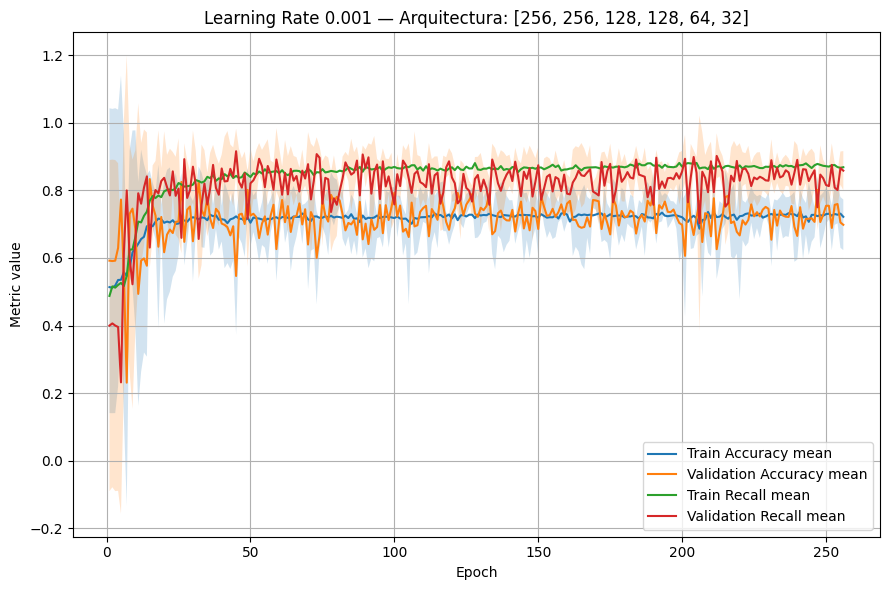

🏃 View run LR 0.001 at: http://localhost:5000/#/experiments/2/runs/00a85a2962694fa0a3449349bfc609da
🧪 View experiment at: http://localhost:5000/#/experiments/2

Entrenando modelo con learning rate: 0.002
Arquitectura fija: [256, 256, 128, 128, 64, 32]
LR 0.002 | Fold 1 terminado — Val Acc: 0.7058, Val Recall: 0.8723, Val F1: 0.1899, Val AUC: 0.8594, Val Loss: 0.4920
LR 0.002 | Fold 2 terminado — Val Acc: 0.6881, Val Recall: 0.8989, Val F1: 0.1856, Val AUC: 0.8516, Val Loss: 0.5540
LR 0.002 | Fold 3 terminado — Val Acc: 0.7865, Val Recall: 0.8032, Val F1: 0.2293, Val AUC: 0.8674, Val Loss: 0.4136
LR 0.002 | Fold 4 terminado — Val Acc: 0.7503, Val Recall: 0.8032, Val F1: 0.2028, Val AUC: 0.8491, Val Loss: 0.4253
LR 0.002 | Fold 5 terminado — Val Acc: 0.7114, Val Recall: 0.8723, Val F1: 0.1929, Val AUC: 0.8488, Val Loss: 0.4887

Promedio de validación para este learning rate:
Learning rate: 0.002
Accuracy promedio: 0.7284
Recall promedio: 0.8500
F1 promedio: 0.2001
AUC promedio: 0.8553
Lo

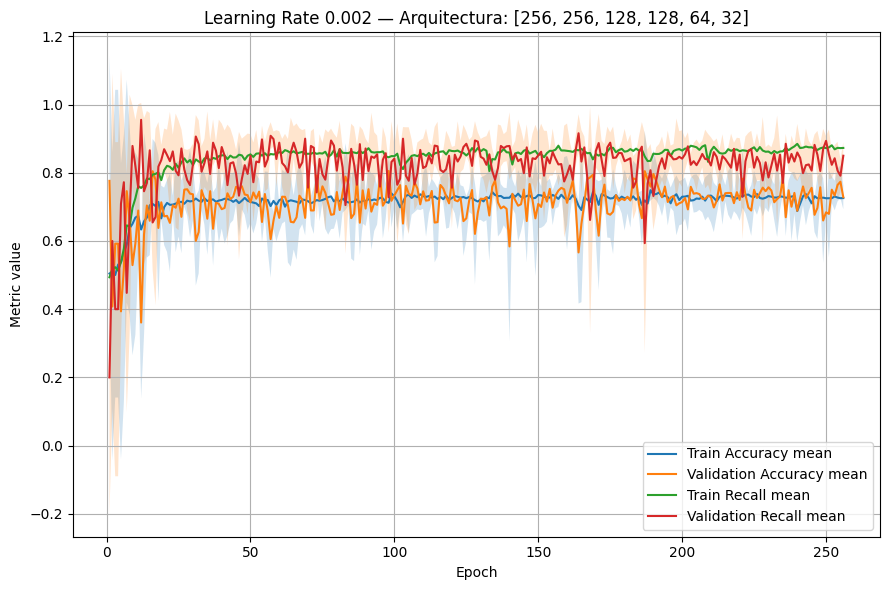

🏃 View run LR 0.002 at: http://localhost:5000/#/experiments/2/runs/4b74b2746de14368a37de0019f983483
🧪 View experiment at: http://localhost:5000/#/experiments/2

Entrenando modelo con learning rate: 0.0035
Arquitectura fija: [256, 256, 128, 128, 64, 32]
LR 0.0035 | Fold 1 terminado — Val Acc: 0.0395, Val Recall: 1.0000, Val F1: 0.0761, Val AUC: 0.5000, Val Loss: 0.6956
LR 0.0035 | Fold 2 terminado — Val Acc: 0.8662, Val Recall: 0.5745, Val F1: 0.2535, Val AUC: 0.8517, Val Loss: 0.2969
LR 0.0035 | Fold 3 terminado — Val Acc: 0.6483, Val Recall: 0.9149, Val F1: 0.1706, Val AUC: 0.8697, Val Loss: 0.6449
LR 0.0035 | Fold 4 terminado — Val Acc: 0.7680, Val Recall: 0.7766, Val F1: 0.2093, Val AUC: 0.8481, Val Loss: 0.4020
LR 0.0035 | Fold 5 terminado — Val Acc: 0.6399, Val Recall: 0.8989, Val F1: 0.1649, Val AUC: 0.8434, Val Loss: 0.6424

Promedio de validación para este learning rate:
Learning rate: 0.0035
Accuracy promedio: 0.5924
Recall promedio: 0.8330
F1 promedio: 0.1749
AUC promedio: 0.

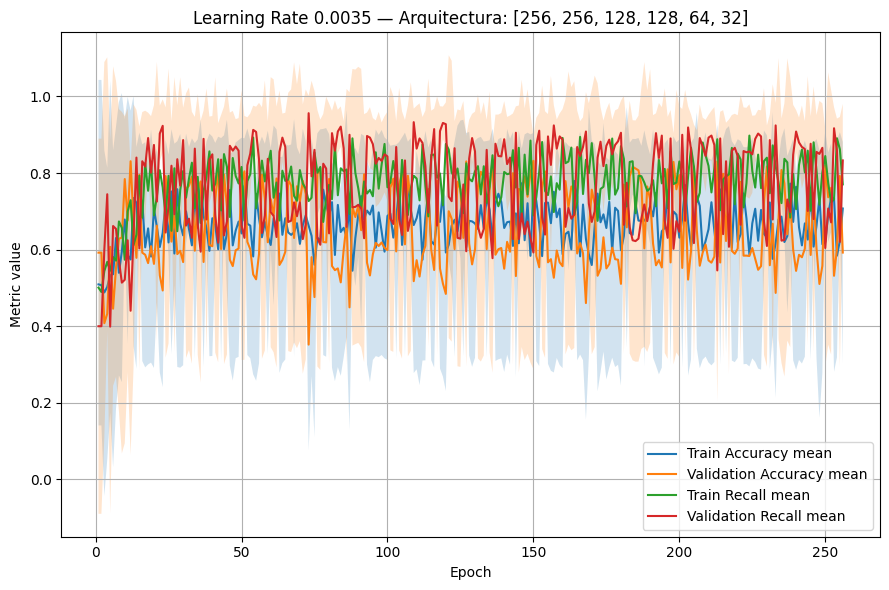

🏃 View run LR 0.0035 at: http://localhost:5000/#/experiments/2/runs/c3d9848a2b5c49f9aca6a7e97313e7fd
🧪 View experiment at: http://localhost:5000/#/experiments/2

Entrenando modelo con learning rate: 0.005
Arquitectura fija: [256, 256, 128, 128, 64, 32]
LR 0.005 | Fold 1 terminado — Val Acc: 0.9605, Val Recall: 0.0000, Val F1: 0.0000, Val AUC: 0.5000, Val Loss: 0.6914
LR 0.005 | Fold 2 terminado — Val Acc: 0.9605, Val Recall: 0.0000, Val F1: 0.0000, Val AUC: 0.5000, Val Loss: 0.6920
LR 0.005 | Fold 3 terminado — Val Acc: 0.0395, Val Recall: 1.0000, Val F1: 0.0761, Val AUC: 0.5000, Val Loss: 0.6973
LR 0.005 | Fold 4 terminado — Val Acc: 0.0395, Val Recall: 1.0000, Val F1: 0.0761, Val AUC: 0.5000, Val Loss: 0.6997
LR 0.005 | Fold 5 terminado — Val Acc: 0.0395, Val Recall: 1.0000, Val F1: 0.0761, Val AUC: 0.5000, Val Loss: 0.6975

Promedio de validación para este learning rate:
Learning rate: 0.005
Accuracy promedio: 0.4079
Recall promedio: 0.6000
F1 promedio: 0.0456
AUC promedio: 0.5000
L

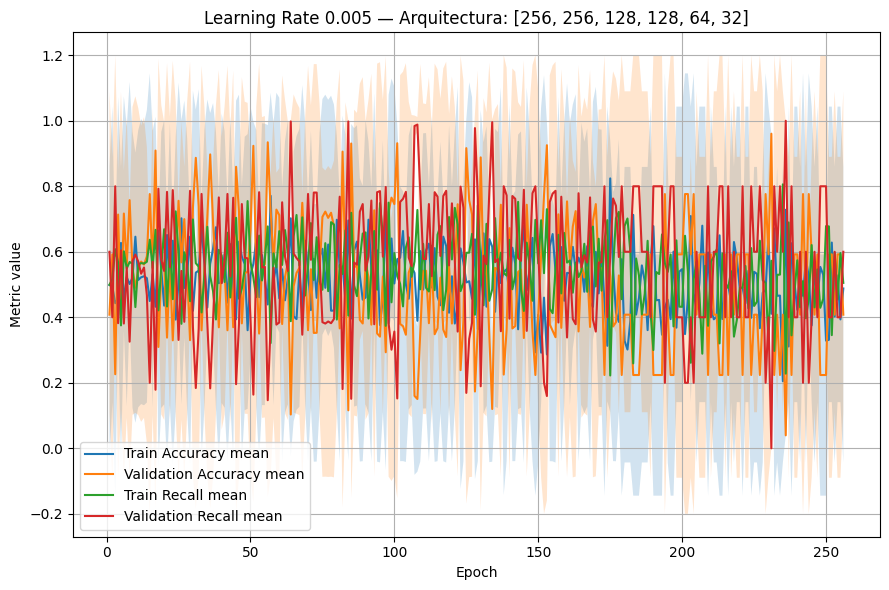

🏃 View run LR 0.005 at: http://localhost:5000/#/experiments/2/runs/da98df72dd5a48d98f602f03f67ad8da
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [14]:
# -------------------------------------------------------
# Stratified K-Fold for learning rate validation
# -------------------------------------------------------

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_lrate = []

all_valid_acc = []
all_train_acc = []
all_valid_recall = []
all_train_recall = []
all_valid_auc = []
all_valid_loss = []

contador = 1

for lrate_actual in learning_rates:

    run_name = f"LR {lrate_actual}"

    with mlflow.start_run(
        experiment_id=experiment.experiment_id,
        run_name=run_name
    ):

        print("\n" + "="*70)
        print(f"Entrenando modelo con learning rate: {lrate_actual}")
        print(f"Arquitectura fija: {arquitectura_fija}")
        print("="*70)

        # -------------------------------------------------------
        # Log hyperparameters in MLflow
        # -------------------------------------------------------

        mlflow.log_param("arquitectura", str(arquitectura_fija))
        mlflow.log_param("num_capas_ocultas", len(arquitectura_fija))
        mlflow.log_param("neuronas_por_capa", str(arquitectura_fija))
        mlflow.log_param("learning_rate", lrate_actual)
        mlflow.log_param("batch_size", batch)
        mlflow.log_param("epochs", pasadas)
        mlflow.log_param("lasso_l1", lasso)
        mlflow.log_param("ridge_l2", ridge)
        mlflow.log_param("dropout", dpout)
        mlflow.log_param("n_splits", 5)
        mlflow.log_param("tipo_validacion", "StratifiedKFold")
        mlflow.log_param("num_descriptores", descr)

        model_valid_acc = []
        model_train_acc = []
        model_valid_recall = []
        model_train_recall = []
        model_valid_auc = []
        model_valid_loss = []

        fold_metrics = []

        best_fold_recall = -1
        best_fold_number = None

        fold_number = 1

        for train_index, val_index in kf.split(X_train, y_train):

            X_tr = X_train.iloc[train_index]
            X_val = X_train.iloc[val_index]

            y_tr = y_train.iloc[train_index]
            y_val = y_train.iloc[val_index]

            # -------------------------------------------------------
            # Class weights for imbalanced target
            # -------------------------------------------------------

            clases = np.unique(y_tr)

            pesos = compute_class_weight(
                class_weight="balanced",
                classes=clases,
                y=y_tr
            )

            class_weight_dict = dict(zip(clases, pesos))

            # -------------------------------------------------------
            # Clear TensorFlow session before each fold
            # -------------------------------------------------------

            tf.keras.backend.clear_session()

            # -------------------------------------------------------
            # Create and train model
            # -------------------------------------------------------

            modelo = creamodelos(
                arquitectura_fija,
                descr,
                lrate_actual,
                dpout,
                lasso,
                ridge
            )

            train = modelo.fit(
                X_tr,
                y_tr,
                batch_size=batch,
                epochs=pasadas,
                validation_data=(X_val, y_val),
                class_weight=class_weight_dict,
                verbose=0
            )

            # -------------------------------------------------------
            # Final epoch metrics from Keras
            # -------------------------------------------------------

            last_train_acc = train.history["accuracy"][-1]
            last_val_acc = train.history["val_accuracy"][-1]
            last_train_recall = train.history["recall"][-1]
            last_val_recall_keras = train.history["val_recall"][-1]
            last_val_auc_keras = train.history["val_auc"][-1]
            last_val_loss = train.history["val_loss"][-1]

            # -------------------------------------------------------
            # Predictions for sklearn metrics
            # -------------------------------------------------------

            y_prob = modelo.predict(X_val, verbose=0).ravel()
            y_pred = (y_prob >= 0.5).astype(int)

            fold_recall = recall_score(y_val, y_pred, zero_division=0)
            fold_f1 = f1_score(y_val, y_pred, zero_division=0)
            fold_auc = roc_auc_score(y_val, y_prob)

            print(
                f"LR {lrate_actual} | Fold {fold_number} terminado — "
                f"Val Acc: {last_val_acc:.4f}, "
                f"Val Recall: {fold_recall:.4f}, "
                f"Val F1: {fold_f1:.4f}, "
                f"Val AUC: {fold_auc:.4f}, "
                f"Val Loss: {last_val_loss:.4f}"
            )

            # -------------------------------------------------------
            # Save curves for plotting only, not as files
            # -------------------------------------------------------

            model_valid_acc.append(np.array(train.history["val_accuracy"]))
            model_train_acc.append(np.array(train.history["accuracy"]))
            model_valid_recall.append(np.array(train.history["val_recall"]))
            model_train_recall.append(np.array(train.history["recall"]))
            model_valid_auc.append(np.array(train.history["val_auc"]))
            model_valid_loss.append(np.array(train.history["val_loss"]))

            # -------------------------------------------------------
            # Save fold metrics in memory
            # -------------------------------------------------------

            fold_result = {
                "modelo": contador,
                "learning_rate": lrate_actual,
                "arquitectura": arquitectura_fija,
                "fold": fold_number,
                "val_accuracy": last_val_acc,
                "val_recall": fold_recall,
                "val_f1": fold_f1,
                "val_auc": fold_auc,
                "val_loss": last_val_loss
            }

            fold_metrics.append(fold_result)
            resultados_lrate.append(fold_result)

            # -------------------------------------------------------
            # Log individual fold metrics in MLflow
            # -------------------------------------------------------

            mlflow.log_metric(f"fold_{fold_number}_val_accuracy", float(last_val_acc))
            mlflow.log_metric(f"fold_{fold_number}_val_recall", float(fold_recall))
            mlflow.log_metric(f"fold_{fold_number}_val_f1", float(fold_f1))
            mlflow.log_metric(f"fold_{fold_number}_val_auc", float(fold_auc))
            mlflow.log_metric(f"fold_{fold_number}_val_loss", float(last_val_loss))

            if fold_recall > best_fold_recall:
                best_fold_recall = fold_recall
                best_fold_number = fold_number

            fold_number += 1

        # -------------------------------------------------------
        # Calculate average metrics across 5 folds
        # -------------------------------------------------------

        df_fold_metrics = pd.DataFrame(fold_metrics)

        mean_val_accuracy = df_fold_metrics["val_accuracy"].mean()
        mean_val_recall = df_fold_metrics["val_recall"].mean()
        mean_val_f1 = df_fold_metrics["val_f1"].mean()
        mean_val_auc = df_fold_metrics["val_auc"].mean()
        mean_val_loss = df_fold_metrics["val_loss"].mean()

        std_val_accuracy = df_fold_metrics["val_accuracy"].std()
        std_val_recall = df_fold_metrics["val_recall"].std()
        std_val_f1 = df_fold_metrics["val_f1"].std()
        std_val_auc = df_fold_metrics["val_auc"].std()
        std_val_loss = df_fold_metrics["val_loss"].std()

        print("\nPromedio de validación para este learning rate:")
        print(f"Learning rate: {lrate_actual}")
        print(f"Accuracy promedio: {mean_val_accuracy:.4f}")
        print(f"Recall promedio: {mean_val_recall:.4f}")
        print(f"F1 promedio: {mean_val_f1:.4f}")
        print(f"AUC promedio: {mean_val_auc:.4f}")
        print(f"Loss promedio: {mean_val_loss:.4f}")

        # -------------------------------------------------------
        # Log average metrics in MLflow
        # -------------------------------------------------------

        mlflow.log_metric("mean_val_accuracy", float(mean_val_accuracy))
        mlflow.log_metric("mean_val_recall", float(mean_val_recall))
        mlflow.log_metric("mean_val_f1", float(mean_val_f1))
        mlflow.log_metric("mean_val_auc", float(mean_val_auc))
        mlflow.log_metric("mean_val_loss", float(mean_val_loss))

        mlflow.log_metric("std_val_accuracy", float(std_val_accuracy))
        mlflow.log_metric("std_val_recall", float(std_val_recall))
        mlflow.log_metric("std_val_f1", float(std_val_f1))
        mlflow.log_metric("std_val_auc", float(std_val_auc))
        mlflow.log_metric("std_val_loss", float(std_val_loss))

        mlflow.log_metric("best_fold_recall", float(best_fold_recall))
        mlflow.log_param("best_fold_number", best_fold_number)

        # -------------------------------------------------------
        # Average curves across folds
        # These are shown in VS Code but NOT saved as PNG
        # -------------------------------------------------------

        val_acc_mean = np.mean(model_valid_acc, axis=0)
        val_acc_std = np.std(model_valid_acc, axis=0)

        train_acc_mean = np.mean(model_train_acc, axis=0)

        val_recall_mean = np.mean(model_valid_recall, axis=0)
        val_recall_std = np.std(model_valid_recall, axis=0)

        train_recall_mean = np.mean(model_train_recall, axis=0)

        epochs_range = np.arange(1, len(val_acc_mean) + 1)

        plt.figure(figsize=(9, 6))

        plt.plot(epochs_range, train_acc_mean, label="Train Accuracy mean")
        plt.plot(epochs_range, val_acc_mean, label="Validation Accuracy mean")
        plt.fill_between(
            epochs_range,
            val_acc_mean - val_acc_std,
            val_acc_mean + val_acc_std,
            alpha=0.2
        )

        plt.plot(epochs_range, train_recall_mean, label="Train Recall mean")
        plt.plot(epochs_range, val_recall_mean, label="Validation Recall mean")
        plt.fill_between(
            epochs_range,
            val_recall_mean - val_recall_std,
            val_recall_mean + val_recall_std,
            alpha=0.2
        )

        plt.xlabel("Epoch")
        plt.ylabel("Metric value")
        plt.title(f"Learning Rate {lrate_actual} — Arquitectura: {arquitectura_fija}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # -------------------------------------------------------
        # Store full curves in memory
        # -------------------------------------------------------

        all_valid_acc.append(np.stack(model_valid_acc))
        all_train_acc.append(np.stack(model_train_acc))
        all_valid_recall.append(np.stack(model_valid_recall))
        all_train_recall.append(np.stack(model_train_recall))
        all_valid_auc.append(np.stack(model_valid_auc))
        all_valid_loss.append(np.stack(model_valid_loss))

    contador += 1

In [15]:
df_resultados_lrate = pd.DataFrame(resultados_lrate)

resumen_lrate = df_resultados_lrate.groupby("learning_rate").agg({
    "val_accuracy": "mean",
    "val_recall": "mean",
    "val_f1": "mean",
    "val_auc": "mean",
    "val_loss": "mean"
}).reset_index()

resumen_lrate = resumen_lrate.rename(columns={
    "val_accuracy": "accuracy_promedio",
    "val_recall": "recall_promedio",
    "val_f1": "f1_promedio",
    "val_auc": "auc_promedio",
    "val_loss": "loss_promedio"
})

resumen_lrate_ordenado = resumen_lrate.sort_values(
    by="recall_promedio",
    ascending=False
)

print(resumen_lrate_ordenado)

   learning_rate  accuracy_promedio  recall_promedio  f1_promedio  \
0         0.0001           0.661437         0.887234     0.179224   
3         0.0010           0.698283         0.858511     0.189985   
4         0.0020           0.728410         0.850000     0.200122   
5         0.0035           0.592384         0.832979     0.174884   
1         0.0003           0.749360         0.817021     0.208139   
2         0.0005           0.764840         0.803191     0.213100   
6         0.0050           0.407911         0.600000     0.045650   

   auc_promedio  loss_promedio  
0      0.855103       0.595534  
3      0.858203       0.522147  
4      0.855273       0.474719  
5      0.782587       0.536351  
1      0.855822       0.438451  
2      0.856938       0.425018  
6      0.500000       0.695572  


In [16]:
# -------------------------------------------------------
# Hyperparameters for batch size experiment
# -------------------------------------------------------

# Best learning rate found in previous experiment
lrate_fija = 0.0001  # Replace with your best learning rate

pasadas = 256

lasso = 0
ridge = 0
dpout = 0

# Best architecture found in previous experiments
arquitectura_fija = [256, 256, 128, 128, 64, 32]

# Batch sizes to evaluate
batch_sizes = [
    16,
    32,
    64,
    128,
    256,
    512,
    1024
]

print("Arquitectura fija:", arquitectura_fija)
print("Learning rate fijo:", lrate_fija)
print("Batch sizes to evaluate:", batch_sizes)

Arquitectura fija: [256, 256, 128, 128, 64, 32]
Learning rate fijo: 0.0001
Batch sizes to evaluate: [16, 32, 64, 128, 256, 512, 1024]


In [17]:
mlflow.set_tracking_uri("http://localhost:5000")

experiment = mlflow.set_experiment("Tamaño de batch")

2026/05/20 00:24:06 INFO mlflow.tracking.fluent: Experiment with name 'Tamaño de batch' does not exist. Creating a new experiment.



Entrenando modelo con batch size: 16
Arquitectura fija: [256, 256, 128, 128, 64, 32]
Learning rate fijo: 0.0001
Batch 16 | Fold 1 terminado — Val Acc: 0.5773, Val Recall: 0.9362, Val F1: 0.1490, Val AUC: 0.8578, Val Loss: 1.0228
Batch 16 | Fold 2 terminado — Val Acc: 0.7417, Val Recall: 0.8511, Val F1: 0.2067, Val AUC: 0.8541, Val Loss: 0.5071
Batch 16 | Fold 3 terminado — Val Acc: 0.6411, Val Recall: 0.9309, Val F1: 0.1702, Val AUC: 0.8694, Val Loss: 1.3400
Batch 16 | Fold 4 terminado — Val Acc: 0.7034, Val Recall: 0.8457, Val F1: 0.1840, Val AUC: 0.8479, Val Loss: 0.7398
Batch 16 | Fold 5 terminado — Val Acc: 0.9605, Val Recall: 0.0000, Val F1: 0.0000, Val AUC: 0.5000, Val Loss: 0.6930

Promedio de validación para este batch size:
Batch size: 16
Accuracy promedio: 0.7248
Recall promedio: 0.7128
F1 promedio: 0.1420
AUC promedio: 0.7858
Loss promedio: 0.8605


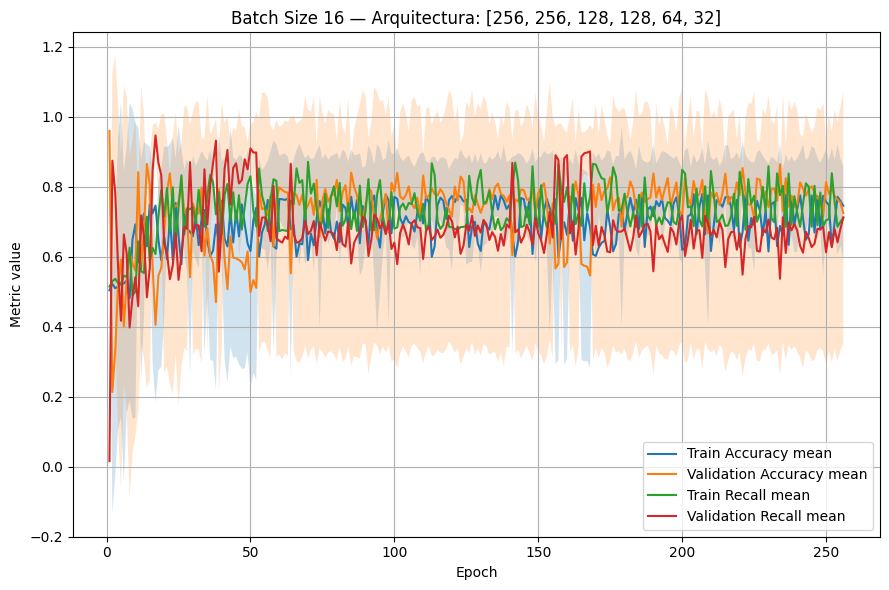

🏃 View run Batch 16 at: http://localhost:5000/#/experiments/3/runs/6ddc93ff17c34a6e87b8f5ff7013392e
🧪 View experiment at: http://localhost:5000/#/experiments/3

Entrenando modelo con batch size: 32
Arquitectura fija: [256, 256, 128, 128, 64, 32]
Learning rate fijo: 0.0001
Batch 32 | Fold 1 terminado — Val Acc: 0.7216, Val Recall: 0.8670, Val F1: 0.1976, Val AUC: 0.8582, Val Loss: 0.4810
Batch 32 | Fold 2 terminado — Val Acc: 0.7238, Val Recall: 0.8617, Val F1: 0.1979, Val AUC: 0.8524, Val Loss: 0.4987
Batch 32 | Fold 3 terminado — Val Acc: 0.7427, Val Recall: 0.8404, Val F1: 0.2053, Val AUC: 0.8694, Val Loss: 0.4974
Batch 32 | Fold 4 terminado — Val Acc: 0.6088, Val Recall: 0.9202, Val F1: 0.1568, Val AUC: 0.8500, Val Loss: 0.6226
Batch 32 | Fold 5 terminado — Val Acc: 0.4758, Val Recall: 0.9415, Val F1: 0.1244, Val AUC: 0.8481, Val Loss: 0.8126

Promedio de validación para este batch size:
Batch size: 32
Accuracy promedio: 0.6545
Recall promedio: 0.8862
F1 promedio: 0.1764
AUC promedi

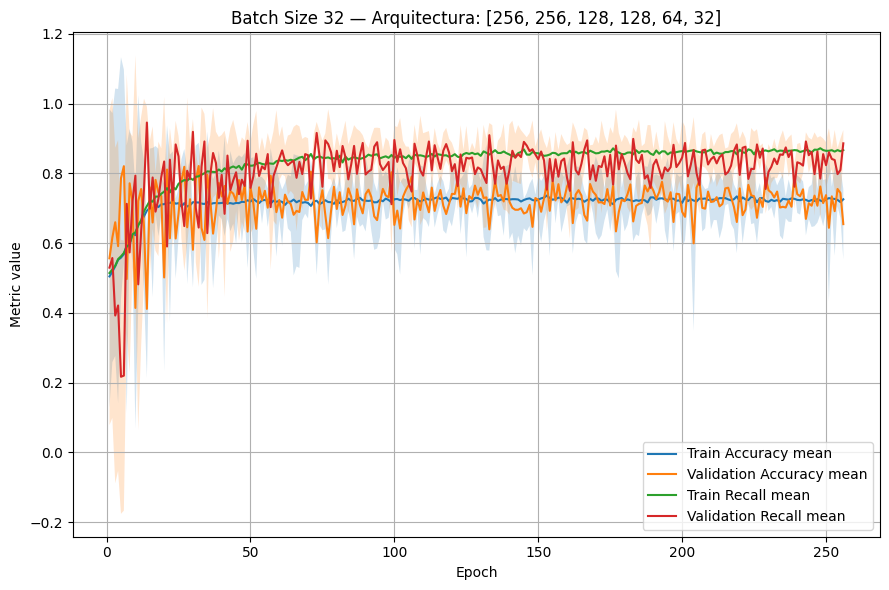

🏃 View run Batch 32 at: http://localhost:5000/#/experiments/3/runs/a136c7ea9f584042a44c9174eb85853b
🧪 View experiment at: http://localhost:5000/#/experiments/3

Entrenando modelo con batch size: 64
Arquitectura fija: [256, 256, 128, 128, 64, 32]
Learning rate fijo: 0.0001
Batch 64 | Fold 1 terminado — Val Acc: 0.6017, Val Recall: 0.9309, Val F1: 0.1560, Val AUC: 0.8569, Val Loss: 0.6452
Batch 64 | Fold 2 terminado — Val Acc: 0.8382, Val Recall: 0.6436, Val F1: 0.2394, Val AUC: 0.8519, Val Loss: 0.3004
Batch 64 | Fold 3 terminado — Val Acc: 0.6925, Val Recall: 0.9096, Val F1: 0.1896, Val AUC: 0.8700, Val Loss: 0.5692
Batch 64 | Fold 4 terminado — Val Acc: 0.7943, Val Recall: 0.7181, Val F1: 0.2163, Val AUC: 0.8498, Val Loss: 0.3722
Batch 64 | Fold 5 terminado — Val Acc: 0.8155, Val Recall: 0.6968, Val F1: 0.2300, Val AUC: 0.8482, Val Loss: 0.3465

Promedio de validación para este batch size:
Batch size: 64
Accuracy promedio: 0.7484
Recall promedio: 0.7798
F1 promedio: 0.2063
AUC promedi

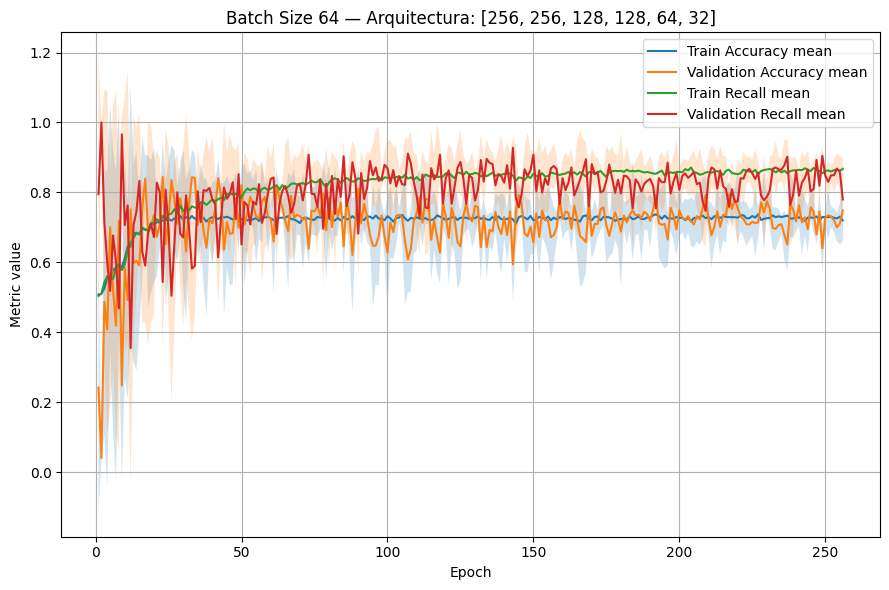

🏃 View run Batch 64 at: http://localhost:5000/#/experiments/3/runs/66927e52b15843cea4810327bb27ceae
🧪 View experiment at: http://localhost:5000/#/experiments/3

Entrenando modelo con batch size: 128
Arquitectura fija: [256, 256, 128, 128, 64, 32]
Learning rate fijo: 0.0001
Batch 128 | Fold 1 terminado — Val Acc: 0.7073, Val Recall: 0.8777, Val F1: 0.1916, Val AUC: 0.8563, Val Loss: 0.4911
Batch 128 | Fold 2 terminado — Val Acc: 0.6538, Val Recall: 0.9096, Val F1: 0.1720, Val AUC: 0.8512, Val Loss: 0.6401
Batch 128 | Fold 3 terminado — Val Acc: 0.7505, Val Recall: 0.8404, Val F1: 0.2104, Val AUC: 0.8700, Val Loss: 0.4777
Batch 128 | Fold 4 terminado — Val Acc: 0.7507, Val Recall: 0.7926, Val F1: 0.2009, Val AUC: 0.8499, Val Loss: 0.4544
Batch 128 | Fold 5 terminado — Val Acc: 0.7892, Val Recall: 0.7553, Val F1: 0.2208, Val AUC: 0.8488, Val Loss: 0.3812

Promedio de validación para este batch size:
Batch size: 128
Accuracy promedio: 0.7303
Recall promedio: 0.8351
F1 promedio: 0.1992
AUC 

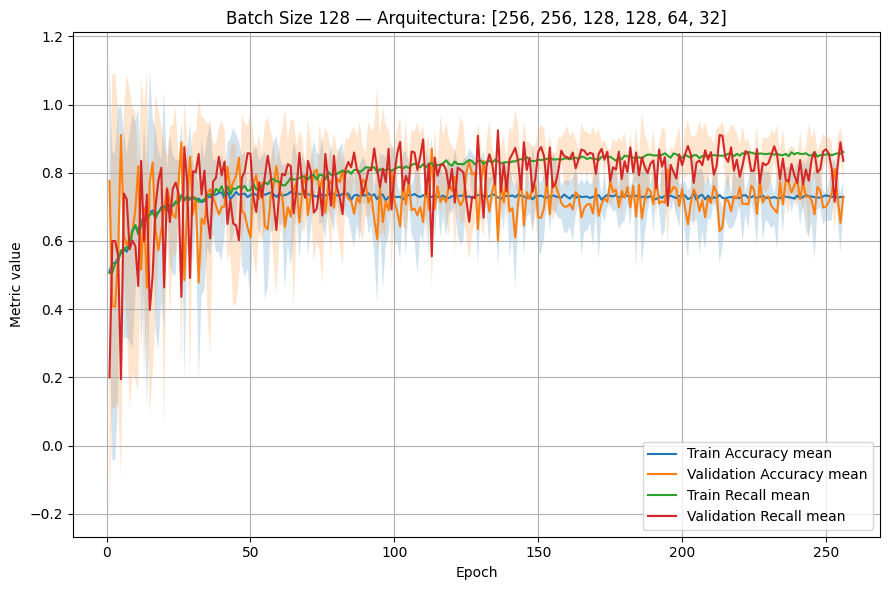

🏃 View run Batch 128 at: http://localhost:5000/#/experiments/3/runs/bcf68f36dd5b4c72866c37c9a7dbfa94
🧪 View experiment at: http://localhost:5000/#/experiments/3

Entrenando modelo con batch size: 256
Arquitectura fija: [256, 256, 128, 128, 64, 32]
Learning rate fijo: 0.0001
Batch 256 | Fold 1 terminado — Val Acc: 0.6976, Val Recall: 0.8830, Val F1: 0.1876, Val AUC: 0.8559, Val Loss: 0.5483
Batch 256 | Fold 2 terminado — Val Acc: 0.5892, Val Recall: 0.9415, Val F1: 0.1534, Val AUC: 0.8510, Val Loss: 0.6729
Batch 256 | Fold 3 terminado — Val Acc: 0.9060, Val Recall: 0.5000, Val F1: 0.2961, Val AUC: 0.8698, Val Loss: 0.2066
Batch 256 | Fold 4 terminado — Val Acc: 0.8111, Val Recall: 0.6809, Val F1: 0.2218, Val AUC: 0.8494, Val Loss: 0.3753
Batch 256 | Fold 5 terminado — Val Acc: 0.7892, Val Recall: 0.7500, Val F1: 0.2196, Val AUC: 0.8485, Val Loss: 0.3692

Promedio de validación para este batch size:
Batch size: 256
Accuracy promedio: 0.7586
Recall promedio: 0.7511
F1 promedio: 0.2157
AUC

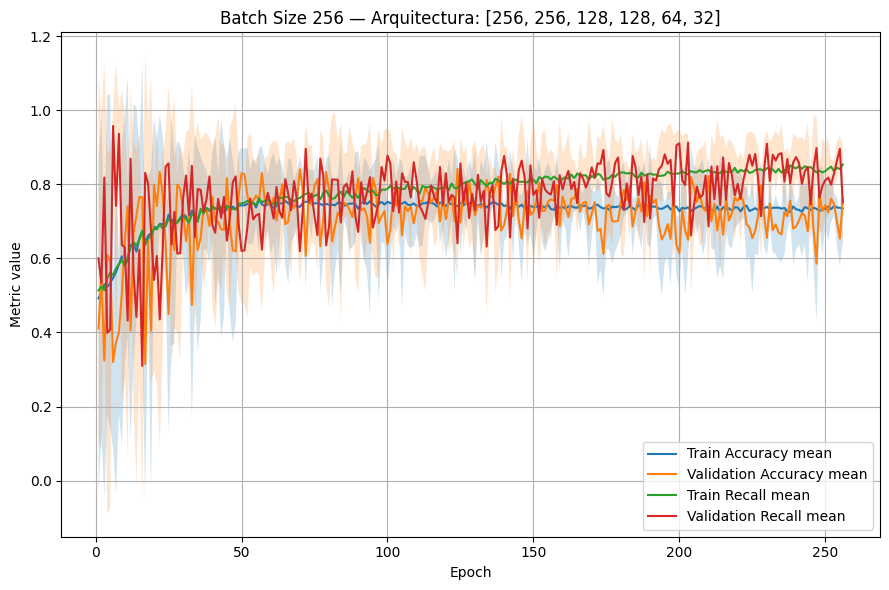

🏃 View run Batch 256 at: http://localhost:5000/#/experiments/3/runs/a8c80863497d4976bf3f2163728c1a65
🧪 View experiment at: http://localhost:5000/#/experiments/3

Entrenando modelo con batch size: 512
Arquitectura fija: [256, 256, 128, 128, 64, 32]
Learning rate fijo: 0.0001
Batch 512 | Fold 1 terminado — Val Acc: 0.7918, Val Recall: 0.7553, Val F1: 0.2229, Val AUC: 0.8542, Val Loss: 0.4304
Batch 512 | Fold 2 terminado — Val Acc: 0.6817, Val Recall: 0.8883, Val F1: 0.1808, Val AUC: 0.8521, Val Loss: 0.6214
Batch 512 | Fold 3 terminado — Val Acc: 0.8035, Val Recall: 0.7660, Val F1: 0.2357, Val AUC: 0.8693, Val Loss: 0.4038
Batch 512 | Fold 4 terminado — Val Acc: 0.7623, Val Recall: 0.7766, Val F1: 0.2053, Val AUC: 0.8473, Val Loss: 0.4625
Batch 512 | Fold 5 terminado — Val Acc: 0.6906, Val Recall: 0.8830, Val F1: 0.1841, Val AUC: 0.8497, Val Loss: 0.6162

Promedio de validación para este batch size:
Batch size: 512
Accuracy promedio: 0.7460
Recall promedio: 0.8138
F1 promedio: 0.2058
AUC

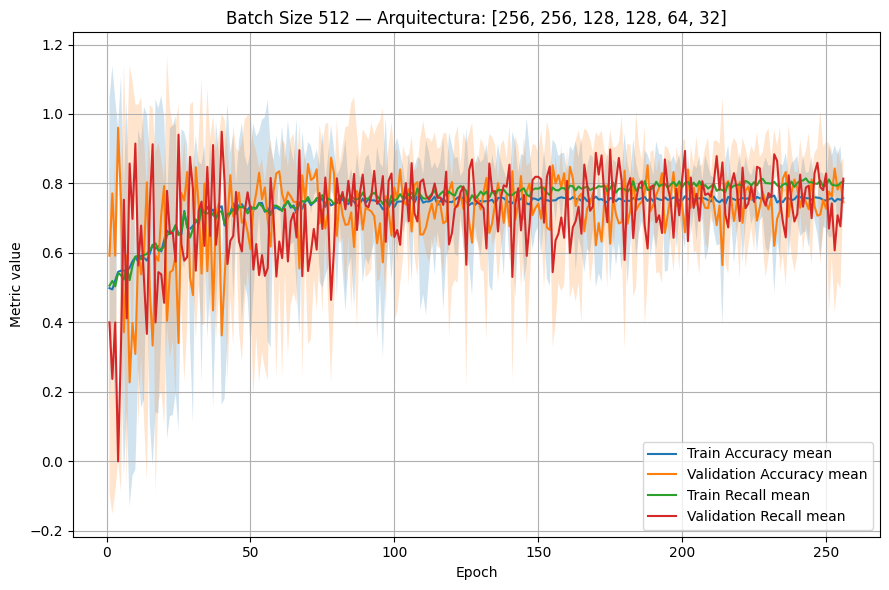

🏃 View run Batch 512 at: http://localhost:5000/#/experiments/3/runs/43de4e7d5dac41809da81a6040d2bbd6
🧪 View experiment at: http://localhost:5000/#/experiments/3

Entrenando modelo con batch size: 1024
Arquitectura fija: [256, 256, 128, 128, 64, 32]
Learning rate fijo: 0.0001
Batch 1024 | Fold 1 terminado — Val Acc: 0.6662, Val Recall: 0.9043, Val F1: 0.1764, Val AUC: 0.8547, Val Loss: 0.6609
Batch 1024 | Fold 2 terminado — Val Acc: 0.6965, Val Recall: 0.8830, Val F1: 0.1870, Val AUC: 0.8473, Val Loss: 0.6220
Batch 1024 | Fold 3 terminado — Val Acc: 0.8652, Val Recall: 0.6649, Val F1: 0.2806, Val AUC: 0.8679, Val Loss: 0.3079
Batch 1024 | Fold 4 terminado — Val Acc: 0.7831, Val Recall: 0.7234, Val F1: 0.2087, Val AUC: 0.8464, Val Loss: 0.4378
Batch 1024 | Fold 5 terminado — Val Acc: 0.6003, Val Recall: 0.9255, Val F1: 0.1548, Val AUC: 0.8493, Val Loss: 0.7949

Promedio de validación para este batch size:
Batch size: 1024
Accuracy promedio: 0.7223
Recall promedio: 0.8202
F1 promedio: 0.2

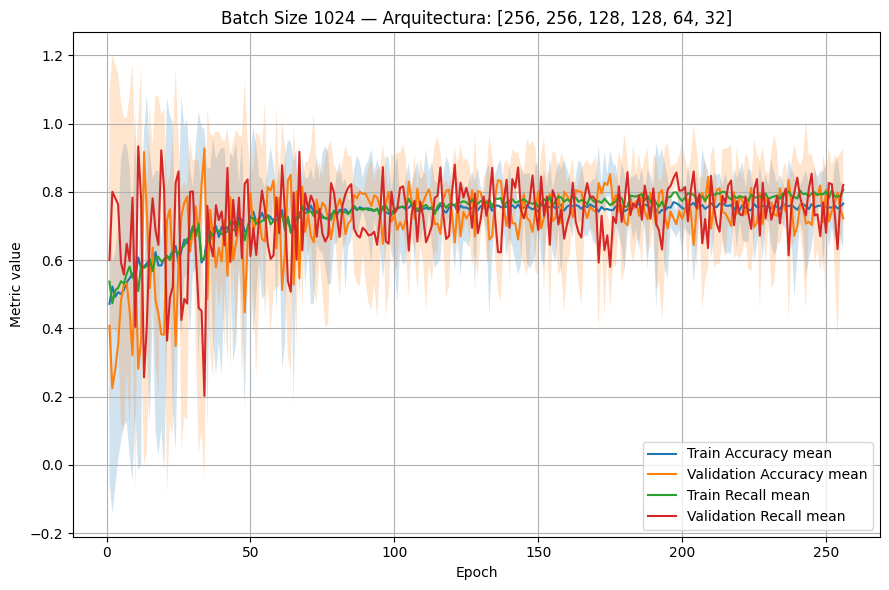

🏃 View run Batch 1024 at: http://localhost:5000/#/experiments/3/runs/85c119aaf82446548cb194f6b1a5355e
🧪 View experiment at: http://localhost:5000/#/experiments/3


In [18]:
# -------------------------------------------------------
# Stratified K-Fold for batch size validation
# -------------------------------------------------------

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_batch = []

all_valid_acc = []
all_train_acc = []
all_valid_recall = []
all_train_recall = []
all_valid_auc = []
all_valid_loss = []

contador = 1

for batch_actual in batch_sizes:

    run_name = f"Batch {batch_actual}"

    with mlflow.start_run(
        experiment_id=experiment.experiment_id,
        run_name=run_name
    ):

        print("\n" + "="*70)
        print(f"Entrenando modelo con batch size: {batch_actual}")
        print(f"Arquitectura fija: {arquitectura_fija}")
        print(f"Learning rate fijo: {lrate_fija}")
        print("="*70)

        # -------------------------------------------------------
        # Log hyperparameters in MLflow
        # -------------------------------------------------------

        mlflow.log_param("arquitectura", str(arquitectura_fija))
        mlflow.log_param("num_capas_ocultas", len(arquitectura_fija))
        mlflow.log_param("neuronas_por_capa", str(arquitectura_fija))
        mlflow.log_param("learning_rate", lrate_fija)
        mlflow.log_param("batch_size", batch_actual)
        mlflow.log_param("epochs", pasadas)
        mlflow.log_param("lasso_l1", lasso)
        mlflow.log_param("ridge_l2", ridge)
        mlflow.log_param("dropout", dpout)
        mlflow.log_param("n_splits", 5)
        mlflow.log_param("tipo_validacion", "StratifiedKFold")
        mlflow.log_param("num_descriptores", descr)

        model_valid_acc = []
        model_train_acc = []
        model_valid_recall = []
        model_train_recall = []
        model_valid_auc = []
        model_valid_loss = []

        fold_metrics = []

        best_fold_recall = -1
        best_fold_number = None

        fold_number = 1

        for train_index, val_index in kf.split(X_train, y_train):

            X_tr = X_train.iloc[train_index]
            X_val = X_train.iloc[val_index]

            y_tr = y_train.iloc[train_index]
            y_val = y_train.iloc[val_index]

            # -------------------------------------------------------
            # Class weights for imbalanced target
            # -------------------------------------------------------

            clases = np.unique(y_tr)

            pesos = compute_class_weight(
                class_weight="balanced",
                classes=clases,
                y=y_tr
            )

            class_weight_dict = dict(zip(clases, pesos))

            # Clear TensorFlow session before each fold
            tf.keras.backend.clear_session()

            # -------------------------------------------------------
            # Create and train model
            # -------------------------------------------------------

            modelo = creamodelos(
                arquitectura_fija,
                descr,
                lrate_fija,
                dpout,
                lasso,
                ridge
            )

            train = modelo.fit(
                X_tr,
                y_tr,
                batch_size=batch_actual,
                epochs=pasadas,
                validation_data=(X_val, y_val),
                class_weight=class_weight_dict,
                verbose=0
            )

            # -------------------------------------------------------
            # Final epoch metrics from Keras
            # -------------------------------------------------------

            last_train_acc = train.history["accuracy"][-1]
            last_val_acc = train.history["val_accuracy"][-1]
            last_train_recall = train.history["recall"][-1]
            last_val_recall_keras = train.history["val_recall"][-1]
            last_val_auc_keras = train.history["val_auc"][-1]
            last_val_loss = train.history["val_loss"][-1]

            # -------------------------------------------------------
            # Predictions for sklearn metrics
            # -------------------------------------------------------

            y_prob = modelo.predict(X_val, verbose=0).ravel()
            y_pred = (y_prob >= 0.5).astype(int)

            fold_recall = recall_score(y_val, y_pred, zero_division=0)
            fold_f1 = f1_score(y_val, y_pred, zero_division=0)
            fold_auc = roc_auc_score(y_val, y_prob)

            print(
                f"Batch {batch_actual} | Fold {fold_number} terminado — "
                f"Val Acc: {last_val_acc:.4f}, "
                f"Val Recall: {fold_recall:.4f}, "
                f"Val F1: {fold_f1:.4f}, "
                f"Val AUC: {fold_auc:.4f}, "
                f"Val Loss: {last_val_loss:.4f}"
            )

            # -------------------------------------------------------
            # Save curves in memory only
            # -------------------------------------------------------

            model_valid_acc.append(np.array(train.history["val_accuracy"]))
            model_train_acc.append(np.array(train.history["accuracy"]))
            model_valid_recall.append(np.array(train.history["val_recall"]))
            model_train_recall.append(np.array(train.history["recall"]))
            model_valid_auc.append(np.array(train.history["val_auc"]))
            model_valid_loss.append(np.array(train.history["val_loss"]))

            # -------------------------------------------------------
            # Save fold metrics in memory
            # -------------------------------------------------------

            fold_result = {
                "modelo": contador,
                "batch_size": batch_actual,
                "learning_rate": lrate_fija,
                "arquitectura": arquitectura_fija,
                "fold": fold_number,
                "val_accuracy": last_val_acc,
                "val_recall": fold_recall,
                "val_f1": fold_f1,
                "val_auc": fold_auc,
                "val_loss": last_val_loss
            }

            fold_metrics.append(fold_result)
            resultados_batch.append(fold_result)

            # -------------------------------------------------------
            # Log individual fold metrics in MLflow
            # -------------------------------------------------------

            mlflow.log_metric(f"fold_{fold_number}_val_accuracy", float(last_val_acc))
            mlflow.log_metric(f"fold_{fold_number}_val_recall", float(fold_recall))
            mlflow.log_metric(f"fold_{fold_number}_val_f1", float(fold_f1))
            mlflow.log_metric(f"fold_{fold_number}_val_auc", float(fold_auc))
            mlflow.log_metric(f"fold_{fold_number}_val_loss", float(last_val_loss))

            if fold_recall > best_fold_recall:
                best_fold_recall = fold_recall
                best_fold_number = fold_number

            fold_number += 1

        # -------------------------------------------------------
        # Calculate average metrics across 5 folds
        # -------------------------------------------------------

        df_fold_metrics = pd.DataFrame(fold_metrics)

        mean_val_accuracy = df_fold_metrics["val_accuracy"].mean()
        mean_val_recall = df_fold_metrics["val_recall"].mean()
        mean_val_f1 = df_fold_metrics["val_f1"].mean()
        mean_val_auc = df_fold_metrics["val_auc"].mean()
        mean_val_loss = df_fold_metrics["val_loss"].mean()

        std_val_accuracy = df_fold_metrics["val_accuracy"].std()
        std_val_recall = df_fold_metrics["val_recall"].std()
        std_val_f1 = df_fold_metrics["val_f1"].std()
        std_val_auc = df_fold_metrics["val_auc"].std()
        std_val_loss = df_fold_metrics["val_loss"].std()

        print("\nPromedio de validación para este batch size:")
        print(f"Batch size: {batch_actual}")
        print(f"Accuracy promedio: {mean_val_accuracy:.4f}")
        print(f"Recall promedio: {mean_val_recall:.4f}")
        print(f"F1 promedio: {mean_val_f1:.4f}")
        print(f"AUC promedio: {mean_val_auc:.4f}")
        print(f"Loss promedio: {mean_val_loss:.4f}")

        # -------------------------------------------------------
        # Log average metrics in MLflow
        # -------------------------------------------------------

        mlflow.log_metric("mean_val_accuracy", float(mean_val_accuracy))
        mlflow.log_metric("mean_val_recall", float(mean_val_recall))
        mlflow.log_metric("mean_val_f1", float(mean_val_f1))
        mlflow.log_metric("mean_val_auc", float(mean_val_auc))
        mlflow.log_metric("mean_val_loss", float(mean_val_loss))

        mlflow.log_metric("std_val_accuracy", float(std_val_accuracy))
        mlflow.log_metric("std_val_recall", float(std_val_recall))
        mlflow.log_metric("std_val_f1", float(std_val_f1))
        mlflow.log_metric("std_val_auc", float(std_val_auc))
        mlflow.log_metric("std_val_loss", float(std_val_loss))

        mlflow.log_metric("best_fold_recall", float(best_fold_recall))
        mlflow.log_param("best_fold_number", best_fold_number)

        # -------------------------------------------------------
        # Average curves across folds
        # Shown in VS Code only, not saved as files
        # -------------------------------------------------------

        val_acc_mean = np.mean(model_valid_acc, axis=0)
        val_acc_std = np.std(model_valid_acc, axis=0)

        train_acc_mean = np.mean(model_train_acc, axis=0)

        val_recall_mean = np.mean(model_valid_recall, axis=0)
        val_recall_std = np.std(model_valid_recall, axis=0)

        train_recall_mean = np.mean(model_train_recall, axis=0)

        epochs_range = np.arange(1, len(val_acc_mean) + 1)

        plt.figure(figsize=(9, 6))

        plt.plot(epochs_range, train_acc_mean, label="Train Accuracy mean")
        plt.plot(epochs_range, val_acc_mean, label="Validation Accuracy mean")
        plt.fill_between(
            epochs_range,
            val_acc_mean - val_acc_std,
            val_acc_mean + val_acc_std,
            alpha=0.2
        )

        plt.plot(epochs_range, train_recall_mean, label="Train Recall mean")
        plt.plot(epochs_range, val_recall_mean, label="Validation Recall mean")
        plt.fill_between(
            epochs_range,
            val_recall_mean - val_recall_std,
            val_recall_mean + val_recall_std,
            alpha=0.2
        )

        plt.xlabel("Epoch")
        plt.ylabel("Metric value")
        plt.title(f"Batch Size {batch_actual} — Arquitectura: {arquitectura_fija}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # -------------------------------------------------------
        # Store full curves in memory
        # -------------------------------------------------------

        all_valid_acc.append(np.stack(model_valid_acc))
        all_train_acc.append(np.stack(model_train_acc))
        all_valid_recall.append(np.stack(model_valid_recall))
        all_train_recall.append(np.stack(model_train_recall))
        all_valid_auc.append(np.stack(model_valid_auc))
        all_valid_loss.append(np.stack(model_valid_loss))

    contador += 1

In [19]:
df_resultados_batch = pd.DataFrame(resultados_batch)

resumen_batch = df_resultados_batch.groupby("batch_size").agg({
    "val_accuracy": "mean",
    "val_recall": "mean",
    "val_f1": "mean",
    "val_auc": "mean",
    "val_loss": "mean"
}).reset_index()

resumen_batch = resumen_batch.rename(columns={
    "val_accuracy": "accuracy_promedio",
    "val_recall": "recall_promedio",
    "val_f1": "f1_promedio",
    "val_auc": "auc_promedio",
    "val_loss": "loss_promedio"
})

resumen_batch_ordenado = resumen_batch.sort_values(
    by="recall_promedio",
    ascending=False
)

print(resumen_batch_ordenado)

   batch_size  accuracy_promedio  recall_promedio  f1_promedio  auc_promedio  \
1          32           0.654534         0.886170     0.176411      0.855610   
3         128           0.730303         0.835106     0.199168      0.855243   
6        1024           0.722269         0.820213     0.201524      0.853133   
5         512           0.745991         0.813830     0.205783      0.854494   
2          64           0.748439         0.779787     0.206258      0.855343   
4         256           0.758616         0.751064     0.215709      0.854939   
0          16           0.724797         0.712766     0.142001      0.785847   

   loss_promedio  
1       0.582437  
3       0.488897  
6       0.564718  
5       0.506833  
2       0.446709  
4       0.434458  
0       0.860537  


In [11]:
# -------------------------------------------------------
# Final hyperparameters
# -------------------------------------------------------

arquitectura_final = [256, 256, 128, 128, 64, 32]

lrate_final = 0.0001
batch_final = 32
pasadas_final = 256

lasso_final = 0
ridge_final = 0
dpout_final = 0

descr = X_train_encoded.shape[1]

print("Número de descriptores:", descr)
print("Arquitectura final:", arquitectura_final)
print("Learning rate final:", lrate_final)
print("Batch size final:", batch_final)
print("Epochs:", pasadas_final)

Número de descriptores: 164
Arquitectura final: [256, 256, 128, 128, 64, 32]
Learning rate final: 0.0001
Batch size final: 32
Epochs: 256


In [12]:
# -------------------------------------------------------
# Make sure data has correct format
# -------------------------------------------------------

X_train_final = X_train_encoded.astype("float32")
X_test_final = X_test_encoded.astype("float32")

y_train_final = y_train.astype(int)
y_test_final = y_test.astype(int)

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)

print("\nTrain class distribution:")
print(y_train_final.value_counts())
print((y_train_final.value_counts(normalize=True) * 100).round(2))

print("\nTest class distribution:")
print(y_test_final.value_counts())
print((y_test_final.value_counts(normalize=True) * 100).round(2))

X_train_final shape: (23771, 164)
X_test_final shape: (5943, 164)

Train class distribution:
cumple_calculo
0    22831
1      940
Name: count, dtype: int64
cumple_calculo
0    96.05
1     3.95
Name: proportion, dtype: float64

Test class distribution:
cumple_calculo
0    5708
1     235
Name: count, dtype: int64
cumple_calculo
0    96.05
1     3.95
Name: proportion, dtype: float64


In [13]:
# -------------------------------------------------------
# Compute class weights for imbalance
# -------------------------------------------------------

clases = np.unique(y_train_final)

pesos = compute_class_weight(
    class_weight="balanced",
    classes=clases,
    y=y_train_final
)

class_weight_dict = dict(zip(clases, pesos))

In [14]:
# -------------------------------------------------------
# MLflow experiment
# -------------------------------------------------------

mlflow.set_tracking_uri("http://localhost:5000")

experiment = mlflow.set_experiment("Prueba de modelo")

2026/05/21 16:17:47 INFO mlflow.tracking.fluent: Experiment with name 'Prueba de modelo' does not exist. Creating a new experiment.


In [17]:
# -------------------------------------------------------
# Train final model and log in MLflow
# -------------------------------------------------------

tf.keras.backend.clear_session()

with mlflow.start_run(
    experiment_id=experiment.experiment_id,
    run_name="Modelo final"
):

    # -------------------------------------------------------
    # Log hyperparameters
    # -------------------------------------------------------

    mlflow.log_param("arquitectura", str(arquitectura_final))
    mlflow.log_param("num_capas_ocultas", len(arquitectura_final))
    mlflow.log_param("neuronas_por_capa", str(arquitectura_final))
    mlflow.log_param("learning_rate", lrate_final)
    mlflow.log_param("batch_size", batch_final)
    mlflow.log_param("epochs", pasadas_final)
    mlflow.log_param("lasso_l1", lasso_final)
    mlflow.log_param("ridge_l2", ridge_final)
    mlflow.log_param("dropout", dpout_final)
    mlflow.log_param("num_descriptores", descr)
    mlflow.log_param("threshold", 0.5)
    mlflow.log_param("class_weight_0", class_weight_dict[0])
    mlflow.log_param("class_weight_1", class_weight_dict[1])

    # -------------------------------------------------------
    # Create model
    # -------------------------------------------------------

    modelo_final = creamodelos(
        arquitectura_final,
        descr,
        lrate_final,
        dpout_final,
        lasso_final,
        ridge_final
    )

    # -------------------------------------------------------
    # Train model on full training set
    # -------------------------------------------------------

    history_final = modelo_final.fit(
        X_train_final,
        y_train_final,
        batch_size=batch_final,
        epochs=pasadas_final,
        class_weight=class_weight_dict,
        verbose=1
    )

    # -------------------------------------------------------
    # Training predictions
    # -------------------------------------------------------

    y_train_prob = modelo_final.predict(X_train_final, verbose=0).ravel()
    y_train_pred = (y_train_prob >= 0.5).astype(int)

    train_accuracy = accuracy_score(y_train_final, y_train_pred)
    train_recall = recall_score(y_train_final, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_final, y_train_pred, zero_division=0)
    train_auc = roc_auc_score(y_train_final, y_train_prob)

    # -------------------------------------------------------
    # Test predictions
    # -------------------------------------------------------

    y_test_prob = modelo_final.predict(X_test_final, verbose=0).ravel()
    y_test_pred = (y_test_prob >= 0.5).astype(int)

    test_accuracy = accuracy_score(y_test_final, y_test_pred)
    test_recall = recall_score(y_test_final, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test_final, y_test_pred, zero_division=0)
    test_auc = roc_auc_score(y_test_final, y_test_prob)

    # -------------------------------------------------------
    # Final training loss from Keras
    # -------------------------------------------------------

    final_train_loss = history_final.history["loss"][-1]
    final_train_accuracy_keras = history_final.history["accuracy"][-1]
    final_train_recall_keras = history_final.history["recall"][-1]
    final_train_auc_keras = history_final.history["auc"][-1]

    # -------------------------------------------------------
    # Log training metrics
    # -------------------------------------------------------

    mlflow.log_metric("train_loss_final_epoch", float(final_train_loss))
    mlflow.log_metric("train_accuracy_final_epoch_keras", float(final_train_accuracy_keras))
    mlflow.log_metric("train_recall_final_epoch_keras", float(final_train_recall_keras))
    mlflow.log_metric("train_auc_final_epoch_keras", float(final_train_auc_keras))

    mlflow.log_metric("train_accuracy", float(train_accuracy))
    mlflow.log_metric("train_recall", float(train_recall))
    mlflow.log_metric("train_f1", float(train_f1))
    mlflow.log_metric("train_auc", float(train_auc))

    # -------------------------------------------------------
    # Log test metrics
    # -------------------------------------------------------

    mlflow.log_metric("test_accuracy", float(test_accuracy))
    mlflow.log_metric("test_recall", float(test_recall))
    mlflow.log_metric("test_f1", float(test_f1))
    mlflow.log_metric("test_auc", float(test_auc))

    # -------------------------------------------------------
    # Log final model
    # -------------------------------------------------------

    mlflow.keras.log_model(
        modelo_final,
        name="modelo-final-keras"
    )

    # -------------------------------------------------------
    # Print results
    # -------------------------------------------------------

    print("\n" + "="*70)
    print("RESULTADOS EN TRAIN")
    print("="*70)
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Train Recall:   {train_recall:.4f}")
    print(f"Train F1-score: {train_f1:.4f}")
    print(f"Train AUC:      {train_auc:.4f}")

    print("\nMatriz de confusión - Train:")
    print(confusion_matrix(y_train_final, y_train_pred))

    print("\n" + "="*70)
    print("RESULTADOS EN TEST")
    print("="*70)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Recall:   {test_recall:.4f}")
    print(f"Test F1-score: {test_f1:.4f}")
    print(f"Test AUC:      {test_auc:.4f}")

    print("\nMatriz de confusión - Test:")
    print(confusion_matrix(y_test_final, y_test_pred))

    print("\nClassification report - Test:")
    print(classification_report(y_test_final, y_test_pred, zero_division=0))

Epoch 1/256
743/743 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4975 - auc: 0.5143 - loss: 0.9531 - recall: 0.5266
Epoch 2/256
743/743 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5049 - auc: 0.5096 - loss: 0.8568 - recall: 0.5245
Epoch 3/256
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5408 - auc: 0.5447 - loss: 0.7617 - recall: 0.5309
Epoch 4/256
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5523 - auc: 0.5646 - loss: 0.7617 - recall: 0.5372
Epoch 5/256
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5323 - auc: 0.5360 - loss: 0.8012 - recall: 0.5277
Epoch 6/256
743/743 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6049 - auc: 0.6299 - loss: 0.6801 - recall: 0.5894
Epoch 7/256
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5743 - auc: 0.6122 - loss: 0.6934 - recall: 0.6000
Epoch 8/256
743/743 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6028 - auc: 0.6548 - loss: 0.6619 - recall: 0.6266
Epoch 9/256
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - a

2026/05/21 21:04:44 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



RESULTADOS EN TRAIN
Train Accuracy: 0.7944
Train Recall:   0.8021
Train F1-score: 0.2358
Train AUC:      0.8772

Matriz de confusión - Train:
[[18130  4701]
 [  186   754]]

RESULTADOS EN TEST
Test Accuracy: 0.7871
Test Recall:   0.7660
Test F1-score: 0.2215
Test AUC:      0.8743

Matriz de confusión - Test:
[[4498 1210]
 [  55  180]]

Classification report - Test:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      5708
           1       0.13      0.77      0.22       235

    accuracy                           0.79      5943
   macro avg       0.56      0.78      0.55      5943
weighted avg       0.95      0.79      0.85      5943

🏃 View run Modelo final at: http://localhost:5000/#/experiments/4/runs/b58635e06f7b40b3a83c95fcad88dce7
🧪 View experiment at: http://localhost:5000/#/experiments/4


In [18]:
modelo_final.save("modelo_final_icfes.keras")